# **Search for Higgs Bosons in the $H \to ZZ \to 2\ell2q$ Channel**

## Code Preliminaries

In [3]:
# Load Packages
!pip install mplhep
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import mplhep as hep
plt.style.use(hep.style.CMS)
from google.colab import drive
drive.mount('/content/drive')
from typing import Optional
import os
from scipy.optimize import curve_fit
from scipy.stats import norm, cauchy
from scipy.optimize import curve_fit, OptimizeWarning
from matplotlib.lines import Line2D
import warnings

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Load the data
dir = "/content/drive/MyDrive/ExP-CMS/Data/"

ZJets = pd.read_csv(dir+'ZJets.csv')
Higgs350 = pd.read_csv(dir+'Higgs2L2Q_M350.csv')
Higgs400 = pd.read_csv(dir+'Higgs2L2Q_M400.csv')
Higgs500 = pd.read_csv(dir+'Higgs2L2Q_M500.csv')
Data = pd.read_csv(dir+'Real-Data.csv')

# Define luminosities
lumi_data = 19.7
lumi_zjets = 33.4
lumi_higgs350 = 305.0
lumi_higgs400 = 541.0
lumi_higgs500 = 1271.0

### Functions & Functionality

#### ``plot_cms``



In [5]:
# ── Default CMS-style colour palettes ────────────────────────────────────────
_BKG_COLORS = [
    "#3182bd", "#e6550d", "#31a354", "#756bb1",
    "#636363", "#6baed6", "#fd8d3c", "#74c476",
]
_SIG_COLORS = ["#e41a1c", "#ff7f00", "#984ea3", "#a65628"]


def plot_cms(
    df,
    var: str,
    x_range: tuple[float, float],
    bins: int,
    xl: Optional[str] = None,
    log: bool = False,
    ylim: Optional[tuple[float, float]] = None,
    mc: Optional[dict] = None,
    lumi_data: Optional[float] = None,
    cms_label: str = "Preliminary",
    com: float = 13,
    ratio: bool = True,
    figsize: Optional[tuple[float, float]] = None,
    yl: str = "Events",
    year: Optional[str] = None,
) -> tuple:
    """
    Produce a CMS-official style histogram.

    Parameters
    ----------
    df : pd.DataFrame
        Observed data.
    var : str
        Column name to histogram.
    x_range : (float, float)
        (x_min, x_max) of the histogram range.
    bins : int
        Number of equal-width bins.
    xl : str, optional
        X-axis label. Defaults to ``var``.
    log : bool
        Use a logarithmic y-axis.
    ylim : (float, float), optional
        Override y-axis limits (useful to leave room for the legend).
    mc : dict, optional
        Monte Carlo processes. Each entry has the form::

            mc = {
                "key": {
                    "df"    : pd.DataFrame,   # required
                    "label" : str,            # required  – legend text
                    "lumi"  : float,          # required  – MC lumi in fb⁻¹
                    "type"  : "bkg" | "sig",  # optional, default "bkg"
                    "color" : str,            # optional  – auto-assigned otherwise
                },
                ...
            }

        Backgrounds are drawn as a **stacked** filled histogram; signals as
        **step** (outline-only) histograms on top.
    lumi_data : float, optional
        Integrated luminosity of the data sample in fb⁻¹.
        Used for MC normalisation (scale = lumi_data / lumi_mc) and the
        header label.
    cms_label : str
        Text next to the CMS logo ("Preliminary", "Work in Progress", etc.).
    com : float
        Centre-of-mass energy in TeV.
    ratio : bool
        Draw a Data / MC ratio panel below the main plot (requires backgrounds).
    figsize : (float, float), optional
        Override figure size. Sensible defaults are chosen automatically.
    yl : str
        Y-axis label (default ``"Events"``).
    year : str, optional
        Data-taking year shown in the header (e.g. ``"2018"``).

    Returns
    -------
    (fig, ax)            when ``ratio=False`` or no backgrounds are present.
    (fig, ax, ax_ratio)  when a ratio panel is drawn.
    """
    hep.style.use("CMS")

    # ── Binning ───────────────────────────────────────────────────────────────
    bin_edges   = np.linspace(x_range[0], x_range[1], bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]
    xl = xl or var

    # ── Parse MC entries ──────────────────────────────────────────────────────
    bkg_entries, sig_entries = [], []
    n_bkg = n_sig = 0

    if mc:
        for key, info in mc.items():
            entry = {**info}  # shallow copy – don't mutate the caller's dict
            etype = entry.get("type", "bkg")

            if "color" not in entry:
                if etype == "bkg":
                    entry["color"] = _BKG_COLORS[n_bkg % len(_BKG_COLORS)]
                else:
                    entry["color"] = _SIG_COLORS[n_sig % len(_SIG_COLORS)]

            scale = (lumi_data / entry["lumi"]) if (lumi_data and entry.get("lumi")) else 1.0
            raw, _ = np.histogram(entry["df"][var], bins=bin_edges)
            entry["counts"] = raw * scale
            entry["errors"] = np.sqrt(raw) * scale
            entry["weights"] = np.full(len(entry["df"]), scale)

            if etype == "bkg":
                bkg_entries.append(entry)
                n_bkg += 1
            else:
                sig_entries.append(entry)
                n_sig += 1

    # ── Data ──────────────────────────────────────────────────────────────────
    counts_data, _ = np.histogram(df[var], bins=bin_edges)
    errors_data    = np.sqrt(counts_data)

    # ── Total background for ratio / uncertainty band ─────────────────────────
    has_bkg = bool(bkg_entries)
    if has_bkg:
        total_bkg     = np.sum([e["counts"] for e in bkg_entries], axis=0)
        total_bkg_err = np.sqrt(np.sum([e["errors"] ** 2 for e in bkg_entries], axis=0))

    show_ratio = ratio and has_bkg

    # ── Figure layout ─────────────────────────────────────────────────────────
    if figsize is None:
        figsize = (10, 11) if show_ratio else (10, 8)

    if show_ratio:
        fig, (ax, ax_ratio) = plt.subplots(
            2, 1,
            figsize=figsize,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.04},
            sharex=True,
        )
    else:
        fig, ax = plt.subplots(figsize=figsize)
        ax_ratio = None

    # ── Stacked backgrounds ───────────────────────────────────────────────────
    if has_bkg:
        ax.hist(
            [e["df"][var] for e in bkg_entries],
            bins=bin_edges,
            weights=[e["weights"] for e in bkg_entries],
            stacked=True,
            histtype="stepfilled",
            color=[e["color"] for e in bkg_entries],
            label=[e["label"] for e in bkg_entries],
            linewidth=0.6,
            edgecolor="black",
        )

        # Hatched statistical-uncertainty band on the total background
        ax.bar(
            bin_centers,
            2 * total_bkg_err,
            bottom=total_bkg - total_bkg_err,
            width=bin_width,
            fill=False,
            edgecolor="dimgrey",
            hatch="////",
            linewidth=0,
            label="Stat. Unc.",
            zorder=3,
        )

    # ── Signal histograms (step lines) ────────────────────────────────────────
    for entry in sig_entries:
        ax.hist(
            entry["df"][var],
            bins=bin_edges,
            weights=entry["weights"],
            histtype="step",
            color=entry["color"],
            label=entry["label"],
            linewidth=2.2,
        )

    # ── Data points ───────────────────────────────────────────────────────────
    ax.errorbar(
        bin_centers,
        counts_data,
        yerr=errors_data,
        fmt="o",
        color="black",
        markersize=5,
        capsize=3,
        elinewidth=1.3,
        label="Data",
        zorder=5,
    )

    # ── CMS header ────────────────────────────────────────────────────────────
    hep.cms.label(
        cms_label,
        data=True,
        lumi=lumi_data,
        com=com,
        year=year,
        ax=ax,
    )

    # ── Main-panel cosmetics ──────────────────────────────────────────────────
    ax.set_ylabel(yl, ha="right", y=1.0)
    ax.legend(loc="upper right", frameon=False, ncols=2 if (n_bkg + n_sig) > 4 else 1)
    ax.set_xlim(*x_range)

    if log:
        ax.set_yscale("log")
    if ylim:
        ax.set_ylim(ylim)
    elif not log:
        ax.set_ylim(bottom=0)

    if not show_ratio:
        ax.set_xlabel(xl, ha="right", x=1.0)

    # ── Ratio panel ───────────────────────────────────────────────────────────
    if show_ratio:
        safe = total_bkg > 0

        ratio_vals    = np.where(safe, counts_data / total_bkg,     np.nan)
        ratio_err     = np.where(safe, errors_data / total_bkg,     np.nan)
        rel_bkg_err   = np.where(safe, total_bkg_err / total_bkg,   np.nan)

        # Shaded MC uncertainty band centred on 1
        ax_ratio.bar(
            bin_centers,
            2 * rel_bkg_err,
            bottom=1.0 - rel_bkg_err,
            width=bin_width,
            color="dimgrey",
            alpha=0.35,
            linewidth=0,
        )

        ax_ratio.errorbar(
            bin_centers,
            ratio_vals,
            yerr=ratio_err,
            fmt="o",
            color="black",
            markersize=5,
            capsize=3,
            elinewidth=1.3,
        )

        ax_ratio.axhline(1.0, color="black", linewidth=0.9, linestyle="--")

        ax_ratio.set_xlabel(xl, ha="right", x=1.0)
        ax_ratio.set_ylabel(r"$\frac{\mathrm{Data}}{\mathrm{MC}}$", fontsize=14)
        ax_ratio.set_ylim(0.5, 1.5)
        ax_ratio.yaxis.set_major_locator(ticker.FixedLocator([0.5, 0.75, 1.0, 1.25, 1.5]))
        ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax_ratio.set_xlim(*x_range)

    fig.align_ylabels()

    if show_ratio:
        return fig, ax, ax_ratio
    return fig, ax

#### ``compare_cms``

In [6]:
# ── Default comparison colour cycle (qualitative, colour-blind friendly) ──────
_CMP_COLORS = [
    "#e41a1c",  # red
    "#377eb8",  # blue
    "#4daf4a",  # green
    "#984ea3",  # purple
    "#ff7f00",  # orange
    "#a65628",  # brown
    "#f781bf",  # pink
    "#999999",  # grey
]

def compare_cms(
    var: str,
    datasets: dict,
    x_range: tuple[float, float],
    bins: int,
    xl: Optional[str] = None,
    yl: Optional[str] = None,
    density: bool = True,
    log: bool = False,
    lumi_ref: Optional[float] = None,
    cms_label: str = "Preliminary",
    com: float = 13,
    figsize: Optional[tuple[float, float]] = None,
    ylim: Optional[tuple[float, float]] = None,
    year: Optional[str] = None,
) -> tuple[plt.Figure, plt.Axes]:
    hep.style.use("CMS")
    """
    CMS-style shape-comparison plot.

    Draws each MC process as a step histogram and each data sample as error-bar
    points.  Designed for cut optimisation, MC validation, and variable studies.

    Parameters
    ----------
    var : str
        Column name to histogram.
    datasets : dict
        One entry per sample.  Each value is a dict with the following keys::

            datasets = {
                "key": {
                    "df"    : pd.DataFrame,   # required
                    "label" : str,            # required  – legend text
                    "lumi"  : float,          # optional  – MC lumi in fb⁻¹
                                              #   (needed only for density=False)
                    "type"  : "mc" | "data",  # optional, default "mc"
                    "color" : str,            # optional  – auto-assigned otherwise
                },
                ...
            }

    x_range : (float, float)
        (x_min, x_max) of the histogram range.
    bins : int
        Number of equal-width bins.
    xl : str, optional
        X-axis label.  Defaults to ``var``.
    yl : str, optional
        Y-axis label.  Defaults to ``"Density"`` or ``"Events"``
        depending on ``density``.
    density : bool
        Normalise each histogram to unit area so that only shapes are compared.
        When ``False``, histograms are scaled to ``lumi_ref`` (if provided).
    log : bool
        Logarithmic y-axis.
    lumi_ref : float, optional
        Reference luminosity in fb⁻¹.  Used for:
        * MC event-count scaling when ``density=False``
          (scale = lumi_ref / lumi_mc).
        * The luminosity shown in the CMS header.
    cms_label : str
        Text next to the CMS logo.  Default ``"Preliminary"``.
    com : float
        Centre-of-mass energy in TeV.
    figsize : (float, float), optional
        Override the default ``(10, 8)`` figure size.
    ylim : (float, float), optional
        Override y-axis limits.
    year : str, optional
        Data-taking year shown in the header.

    Returns
    -------
    (fig, ax)

    Notes
    -----
    * In ``density=True`` mode luminosity weights cancel in the normalisation,
      so ``lumi_ref`` / ``lumi`` have no effect on the shapes drawn—only on the
      header label.
    * Poisson errors on data points are propagated as
      ``σ_density = √N_i / (N_total · Δx)`` per bin.
    """
    # ── Binning ───────────────────────────────────────────────────────────────
    bin_edges   = np.linspace(x_range[0], x_range[1], bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]
    xl = xl or var

    # ── Parse entries ─────────────────────────────────────────────────────────
    mc_entries, data_entries = [], []
    has_data = False
    color_idx = 0

    for key, info in datasets.items():
        entry = {**info}
        etype = entry.get("type", "mc")

        if etype == "data":
            entry["color"] = entry.get("color", "black")  # black by default, overridable
        else:
            if "color" not in entry:
                entry["color"] = _CMP_COLORS[color_idx % len(_CMP_COLORS)]
            color_idx += 1  # only advance the MC palette for MC entries

        raw_counts, _ = np.histogram(entry["df"][var], bins=bin_edges)

        if etype == "data":
            has_data = True
            n_total = raw_counts.sum()
            if density and n_total > 0:
                entry["vals"] = raw_counts / (n_total * bin_width)
                entry["errs"] = np.sqrt(raw_counts) / (n_total * bin_width)
            else:
                entry["vals"] = raw_counts.astype(float)
                entry["errs"] = np.sqrt(raw_counts.astype(float))
            data_entries.append(entry)

        else:
            if density:
                entry["weights"] = np.ones(len(entry["df"]))
                entry["density"] = True
            else:
                scale = (lumi_ref / entry["lumi"]) if (lumi_ref and entry.get("lumi")) else 1.0
                entry["weights"] = np.full(len(entry["df"]), scale)
                entry["density"] = False
            mc_entries.append(entry)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize or (10, 8))

    # ── MC step histograms ────────────────────────────────────────────────────
    for entry in mc_entries:
        ax.hist(
            entry["df"][var],
            bins=bin_edges,
            weights=entry["weights"],
            density=entry["density"],
            histtype="step",
            color=entry["color"],
            label=entry["label"],
            linewidth=2.0,
        )

    # ── Data error-bar points ─────────────────────────────────────────────────
    for entry in data_entries:
        ax.errorbar(
            bin_centers,
            entry["vals"],
            yerr=entry["errs"],
            fmt="o",
            color=entry["color"],
            markersize=5,
            capsize=3,
            elinewidth=1.3,
            label=entry["label"],
            zorder=5,
        )

    # ── CMS header ────────────────────────────────────────────────────────────
    hep.cms.label(
        cms_label,
        data=has_data,
        lumi=lumi_ref if has_data else None,
        com=com,
        year=year,
        ax=ax,
    )

    # ── Cosmetics ─────────────────────────────────────────────────────────────
    if yl is None:
        yl = "Density" if density else "Events"

    ax.set_ylabel(yl, ha="right", y=1.0)
    ax.set_xlabel(xl, ha="right", x=1.0)
    ax.legend(loc="upper right", frameon=False)
    ax.set_xlim(*x_range)

    if log:
        ax.set_yscale("log")
    if ylim:
        ax.set_ylim(ylim)
    elif not log:
        ax.set_ylim(bottom=0)

    return fig, ax

#### ``calculate_invariant_mass``

In [7]:
def kinematic_to_cartesian(df, prefix):
    # Particle 1
    pt1 = df[f'pt{prefix}1']
    eta1 = df[f'eta{prefix}1']
    phi1 = df[f'phi{prefix}1']
    e1 = df[f'e{prefix}1']

    df[f'px{prefix}1'] = pt1 * np.cos(phi1)
    df[f'py{prefix}1'] = pt1 * np.sin(phi1)
    df[f'pz{prefix}1'] = pt1 * np.sinh(eta1)
    df[f'E{prefix}1'] = e1

    # Particle 2
    pt2 = df[f'pt{prefix}2']
    eta2 = df[f'eta{prefix}2']
    phi2 = df[f'phi{prefix}2']
    e2 = df[f'e{prefix}2']

    df[f'px{prefix}2'] = pt2 * np.cos(phi2)
    df[f'py{prefix}2'] = pt2 * np.sin(phi2)
    df[f'pz{prefix}2'] = pt2 * np.sinh(eta2)
    df[f'E{prefix}2'] = e2

    return df

def calculate_invariant_mass(E1, px1, py1, pz1, E2, px2, py2, pz2):
    sum_E = E1 + E2
    sum_px = px1 + px2
    sum_py = py1 + py2
    sum_pz = pz1 + pz2
    return np.sqrt(sum_E**2 - (sum_px**2 + sum_py**2 + sum_pz**2))

def calculate_invariant_mass_four_particles(E1, px1, py1, pz1, E2, px2, py2, pz2, E3, px3, py3, pz3, E4, px4, py4, pz4):
    sum_E = E1 + E2 + E3 + E4
    sum_px = px1 + px2 + px3 + px4
    sum_py = py1 + py2 + py3 + py4
    sum_pz = pz1 + pz2 + pz3 + pz4
    return np.sqrt(sum_E**2 - (sum_px**2 + sum_py**2 + sum_pz**2))

# List of dataframes to process
df_list = [ZJets, Higgs350, Higgs400, Higgs500, Data]
df_names = ['ZJets', 'Higgs350', 'Higgs400', 'Higgs500', 'Data']

for i, df in enumerate(df_list):
    # Convert lepton kinematic variables to Cartesian coordinates
    df = kinematic_to_cartesian(df, 'l')

    # Convert jet kinematic variables to Cartesian coordinates
    df = kinematic_to_cartesian(df, 'j')

    # Calculate Mll (dilepton invariant mass)
    df['Mll'] = calculate_invariant_mass(df['El1'], df['pxl1'], df['pyl1'], df['pzl1'],
                                        df['El2'], df['pxl2'], df['pyl2'], df['pzl2'])

    # Calculate Mjj (dijet invariant mass)
    df['Mjj'] = calculate_invariant_mass(df['Ej1'], df['pxj1'], df['pyj1'], df['pzj1'],
                                        df['Ej2'], df['pxj2'], df['pyj2'], df['pzj2'])

    # Calculate Mlljj (total invariant mass of the 2-lepton, 2-jet system)
    df['Mlljj'] = calculate_invariant_mass_four_particles(df['El1'], df['pxl1'], df['pyl1'], df['pzl1'],
                                                        df['El2'], df['pxl2'], df['pyl2'], df['pzl2'],
                                                        df['Ej1'], df['pxj1'], df['pyj1'], df['pzj1'],
                                                        df['Ej2'], df['pxj2'], df['pyj2'], df['pzj2'])

    df_list[i] = df # Update the dataframe in the list

    print(f"Updated {df_names[i]} with Cartesian coordinates and invariant masses.")
    #display(df.head())

# Reassign the modified dataframes back to their original names
ZJets, Higgs350, Higgs400, Higgs500, Data = df_list

Updated ZJets with Cartesian coordinates and invariant masses.
Updated Higgs350 with Cartesian coordinates and invariant masses.
Updated Higgs400 with Cartesian coordinates and invariant masses.
Updated Higgs500 with Cartesian coordinates and invariant masses.
Updated Data with Cartesian coordinates and invariant masses.


#### ``find_cut``

In [8]:
def find_cut(sgn, bkg, var, lumi_sgn, lumi_bkg, lumi_data, n_scan=500, minN=10):
    # Arrays with the values
    s_vals_raw = sgn[var].values
    b_vals_raw = bkg[var].values

    # Calculate luminosity weights
    weight_sgn = lumi_data / lumi_sgn
    weight_bkg = lumi_data / lumi_bkg

    # Total number of events scaled by luminosity
    N_S_total_scaled = len(s_vals_raw) * weight_sgn
    N_B_total_scaled = len(b_vals_raw) * weight_bkg

    # Find the limits of values
    lo = min(s_vals_raw.min(), b_vals_raw.min())
    hi = max(s_vals_raw.max(), b_vals_raw.max())

    # Scan over the combined range of both distributions
    cuts = np.linspace(lo, hi, n_scan)
    S_values = np.full(n_scan, np.nan)
    S_scaled_values = np.full(n_scan, np.nan)

    for i, X in enumerate(cuts):
        # Number of events passing the cut, scaled by luminosity
        N_S_cut_scaled = np.sum(s_vals_raw > X) * weight_sgn
        N_B_cut_scaled = np.sum(b_vals_raw > X) * weight_bkg

        if (N_S_cut_scaled + N_B_cut_scaled) >= minN:
            S_scaled_values[i] = N_S_cut_scaled / np.sqrt(10*N_S_cut_scaled + N_B_cut_scaled)
        if N_B_cut_scaled > 0:
            S_values[i] = N_S_cut_scaled / np.sqrt(N_B_cut_scaled)

    best_idx = np.nanargmax(S_scaled_values)
    best_cut = cuts[best_idx]

    # Calculate values for the returned dictionary using scaled counts
    total_significance = N_S_total_scaled / np.sqrt(N_B_total_scaled)
    scaled_significance_at_best_cut = S_scaled_values[best_idx]
    significance_at_best_cut = S_values[best_idx]

    # Efficiencies should be based on raw (unscaled) event counts as they represent acceptance
    eff_signal = np.sum(s_vals_raw > best_cut) / len(s_vals_raw)
    eff_bkg = np.sum(b_vals_raw > best_cut) / len(b_vals_raw)

    return {
        "best_cut": best_cut,
        "total_significance": total_significance,
        "scaled_significance": scaled_significance_at_best_cut,
        "significance": significance_at_best_cut,
        "cuts": cuts,
        "S_scaled_values": S_scaled_values,
        "S_values": S_values,
        "eff_signal": eff_signal,
        "eff_bkg": eff_bkg
    }

def plot_cut(sgn, bkg, var, result, x_range=None, xl=None):
    s_vals  = sgn[var].values
    b_vals  = bkg[var].values
    X_best  = result["best_cut"]

    if x_range:
        bins = np.linspace(x_range[0], x_range[1], 70)
    else:
        bins = np.linspace(min(s_vals.min(), b_vals.min()),
                          max(s_vals.max(), b_vals.max()), 60)

    # Create a single figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(19, 8))
    fig.tight_layout(w_pad=3)

    # Plot 1: Distributions
    ax1.hist(b_vals, bins=bins, density=True,
             color="r", label="Background", histtype='step', linewidth=1.5)
    ax1.hist(s_vals, bins=bins, density=True,
             color="b", label="Signal", histtype='step', linewidth=1.5)
    ax1.axvline(X_best, color="k", lw=1.5, ls="--",
                label=f"X = {X_best:.3f}")

    hep.cms.label("Preliminary", data=False, lumi=lumi_data, com=8, ax=ax1)

    ylim = ax1.get_ylim()

    ax1.set_xlabel(xl if xl else var)
    ax1.set_ylabel("Density")
    ax1.legend()
    ax1.set_ylim(ylim)
    # Plot 2: Significance curve
    ax2.plot(result["cuts"], result["S_scaled_values"],
             color="m", lw=1.5, label=r"$N_S\,/\,\sqrt{10 N_S + N_B}$")
    ax2.plot(result["cuts"], result["S_values"],
             color="orange", lw=1.5, ls='-.', label=r"$N_S\,/\,\sqrt{N_B}$")
    ax2.axvline(X_best, color="k", lw=1.5, ls="--",
                label=f"X = {X_best:.3f}\n"
                      f"$R_S$ = {result['significance']/result['total_significance']:.2f}\n"
                      f"$ε_{{sig}}$ = {result['eff_signal']:.1%}\n"
                      f"$ε_{{bkg}}$ = {result['eff_bkg']:.1%}")
    #ax2.scatter([X_best], [result["scaled_significance"]],color="k", zorder=5, s=50)
    ax2.set_xlabel(xl if xl else var,)
    ax2.set_ylabel(r"Significance")
    ax2.legend()

    hep.cms.label("Preliminary", data=False, lumi=lumi_data, com=8, ax=ax2)

    if x_range:
        ax2.set_xlim(x_range)

    plt.show()

#### ``fit_cms``

In [9]:
_CMS_BLUE = "#377eb8"
_CMS_RED  = "#e41a1c"   # CMS official "red" is actually this amber/orange in the palette


# ── Fit models ────────────────────────────────────────────────────────────────
def _gaussian_model(x, A, mu, sigma):
    """Unnormalised Gaussian."""
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def _breit_wigner_model(x, A, M, Gamma):
    """Non-relativistic Breit-Wigner."""
    return A * (Gamma / 2) ** 2 / ((x - M) ** 2 + (Gamma / 2) ** 2)

def _smart_fmt(val, err):
    """Format val ± err to 1 significant figure of the error."""
    if not np.isfinite(err) or err <= 0:
        return f"{val:.4g}", "?"
    mag      = int(np.floor(np.log10(err)))
    decimals = max(0, -mag)                  # 1 sig fig
    return f"{val:.{decimals}f}", f"{err:.{decimals}f}"

_no_handle = Line2D([0], [0], color="none")

def fit_cms(
    var: str,
    df: pd.DataFrame,
    x_range: tuple[float, float],
    bins: int,
    fit_range: Optional[tuple[float, float]] = None,
    label: str = "MC",
    data_type: str = "mc",          # "mc" → step histogram | "data" → error-bar points
    lumi: Optional[float] = None,   # sample lumi (for header when data_type="data")
    xl: Optional[str] = None,
    yl: Optional[str] = None,
    density: bool = True,
    log: bool = False,
    lumi_ref: Optional[float] = None,
    cms_label: str = "Preliminary",
    com: float = 13,
    figsize: Optional[tuple[float, float]] = None,
    ylim: Optional[tuple[float, float]] = None,
    year: Optional[str] = None,
) -> tuple[plt.Figure, plt.Axes]:
    """
    CMS-style single-sample histogram with Breit-Wigner and Normal fits.

    The histogram is drawn in black (error-bar points for data, step for MC).
    The Breit-Wigner fit is drawn in CMS blue  (solid  ─────).
    The Normal fit        is drawn in CMS red   (dash-dot ─·─).
    Fit parameters appear in an external legend to the right.

    Parameters
    ----------
    var : str
        Column name to histogram and fit.
    df : pd.DataFrame
        Sample to plot and fit.
    x_range : (float, float)
        Full (x_min, x_max) of the histogram and plot.
    bins : int
        Number of equal-width bins.
    fit_range : (float, float), optional
        Sub-range used for fitting.  Defaults to ``x_range``.
        Dotted vertical guide lines are drawn at the boundaries when this
        differs from ``x_range``.
    label : str
        Legend label for the histogram (default ``"MC"``).
    data_type : {"mc", "data"}
        ``"data"`` → error-bar points.  ``"mc"`` → step histogram.
    lumi : float, optional
        Sample luminosity in fb⁻¹ shown in the CMS header when
        ``data_type="data"``.
    xl : str, optional
        X-axis label.  Defaults to ``var``.
    yl : str, optional
        Y-axis label.  Defaults to ``"Density"`` or ``"Events"``.
    density : bool
        Normalise to unit area.
    log : bool
        Logarithmic y-axis.
    lumi_ref : float, optional
        Shown in the CMS header (``data_type="data"`` only).
    cms_label : str
        Text next to the CMS logo.
    com : float
        Centre-of-mass energy in TeV.
    figsize : (float, float), optional
        Override figure size (default ``(10, 8)``).
    ylim : (float, float), optional
        Override y-axis limits.
    year : str, optional
        Data-taking year shown in the header.

    Returns
    -------
    (fig, ax)

    Notes
    -----
    Save with ``fig.savefig(..., bbox_inches='tight')`` to include the legend.
    """
    hep.style.use("CMS")

    fit_range = fit_range or x_range
    xl        = xl or var

    # ── Binning ───────────────────────────────────────────────────────────────
    bin_edges   = np.linspace(x_range[0], x_range[1], bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]

    # ── Counts ────────────────────────────────────────────────────────────────
    raw, _ = np.histogram(df[var], bins=bin_edges)

    if density:
        n_total = raw.sum()
        vals    = raw / (n_total * bin_width) if n_total > 0 else raw.astype(float)
        errs    = np.sqrt(raw) / (n_total * bin_width) if n_total > 0 else np.zeros_like(raw, dtype=float)
    else:
        vals = raw.astype(float)
        errs = np.sqrt(raw).astype(float)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize or (10, 8))

    leg_h, leg_l = [], []

    # ── Histogram ─────────────────────────────────────────────────────────────
    if data_type == "data":
        ep = ax.errorbar(
            bin_centers, vals, yerr=errs,
            fmt="o", color="black", markersize=5,
            capsize=3, elinewidth=1.3, zorder=5,
        )
        leg_h.append(ep)
    else:
        ax.hist(
            df[var], bins=bin_edges,
            weights=np.ones(len(df)) if density else None,
            density=density,
            histtype="step", color="black", linewidth=2.0,
        )
        leg_h.append(Line2D([0], [0], color="black", linewidth=2.0))

    leg_l.append(label)

    # ── Fit arrays (fit_range, non-zero bins only) ────────────────────────────
    fit_mask  = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1])
    valid     = fit_mask & (errs > 0)
    xf, yf    = bin_centers[valid], vals[valid]
    sigma_fit = errs[valid]

    if len(xf) >= 3:
        peak_i = np.argmax(yf)
        A0, M0 = yf[peak_i], xf[peak_i]
        w0     = (fit_range[1] - fit_range[0]) / 4
        x_curve = np.linspace(x_range[0], x_range[1], 800)

        # ── Breit-Wigner ──────────────────────────────────────────────────
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", OptimizeWarning)
                popt_bw, pcov_bw = curve_fit(
                    _breit_wigner_model, xf, yf,
                    p0=[A0, M0, w0],
                    sigma=sigma_fit, absolute_sigma=True,
                    maxfev=10_000,
                )
            perr_bw         = np.sqrt(np.diag(pcov_bw))
            _, M_bw,  G_bw  = popt_bw
            _, M_err, G_err = perr_bw
            M_s,  Me_s      = _smart_fmt(M_bw,      M_err)
            G_s,  Ge_s      = _smart_fmt(abs(G_bw),  G_err)

            bw_line, = ax.plot(
                x_curve, _breit_wigner_model(x_curve, *popt_bw),
                color=_CMS_BLUE, linewidth=2.2, linestyle="-",
            )
            leg_h += [bw_line,          _no_handle,                     _no_handle]
            leg_l += ["Breit-Wigner fit",
                      rf"$M = {M_s} \pm {Me_s}$",
                      rf"$\Gamma = {G_s} \pm {Ge_s}$"]
        except Exception as exc:
            print(f"[fit_cms] BW fit failed: {exc}")

        # ── Normal ────────────────────────────────────────────────────────
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", OptimizeWarning)
                popt_norm, pcov_norm = curve_fit(
                    _gaussian_model, xf, yf,
                    p0=[A0, M0, w0],
                    sigma=sigma_fit, absolute_sigma=True,
                    maxfev=10_000,
                )
            perr_norm         = np.sqrt(np.diag(pcov_norm))
            _, mu_n,  sig_n   = popt_norm
            _, mu_e,  sig_e   = perr_norm
            mu_s,  mue_s      = _smart_fmt(mu_n,      mu_e)
            sig_s, sige_s     = _smart_fmt(abs(sig_n), sig_e)

            norm_line, = ax.plot(
                x_curve, _gaussian_model(x_curve, *popt_norm),
                color=_CMS_RED, linewidth=2.2, linestyle="-.",
            )
            leg_h += [norm_line,    _no_handle,                     _no_handle]
            leg_l += ["Normal fit",
                      rf"$\mu = {mu_s} \pm {mue_s}$",
                      rf"$\sigma = {sig_s} \pm {sige_s}$"]
        except Exception as exc:
            print(f"[fit_cms] Normal fit failed: {exc}")
    else:
        print("[fit_cms] Fewer than 3 valid bins in fit_range – fits skipped.")

    # ── Fit-range guide lines ─────────────────────────────────────────────────
    if fit_range != x_range:
        for xv in fit_range:
            ax.axvline(xv, color="dimgrey", linewidth=0.9,
                       linestyle=":", zorder=1, alpha=0.7)

    # ── CMS header ────────────────────────────────────────────────────────────
    is_data = data_type == "data"
    hep.cms.label(
        cms_label,
        data=is_data,
        lumi=lumi_ref if is_data else None,
        com=com,
        year=year,
        ax=ax,
    )

    # ── Cosmetics ─────────────────────────────────────────────────────────────
    if yl is None:
        yl = "Density" if density else "Events"

    ax.set_ylabel(yl, ha="right", y=1.0)
    ax.set_xlabel(xl, ha="right", x=1.0)
    ax.legend(
        handles=leg_h, labels=leg_l, frameon=False, handlelength=1.8,
    )
    ax.set_xlim(*x_range)

    if log:
        ax.set_yscale("log")
    if ylim:
        ax.set_ylim(ylim)
    elif not log:
        ax.set_ylim(bottom=0)

    fig.tight_layout()
    return fig, ax

## Essential Cuts

## Fitting of $M_{ll}$ and $M_{jj}$

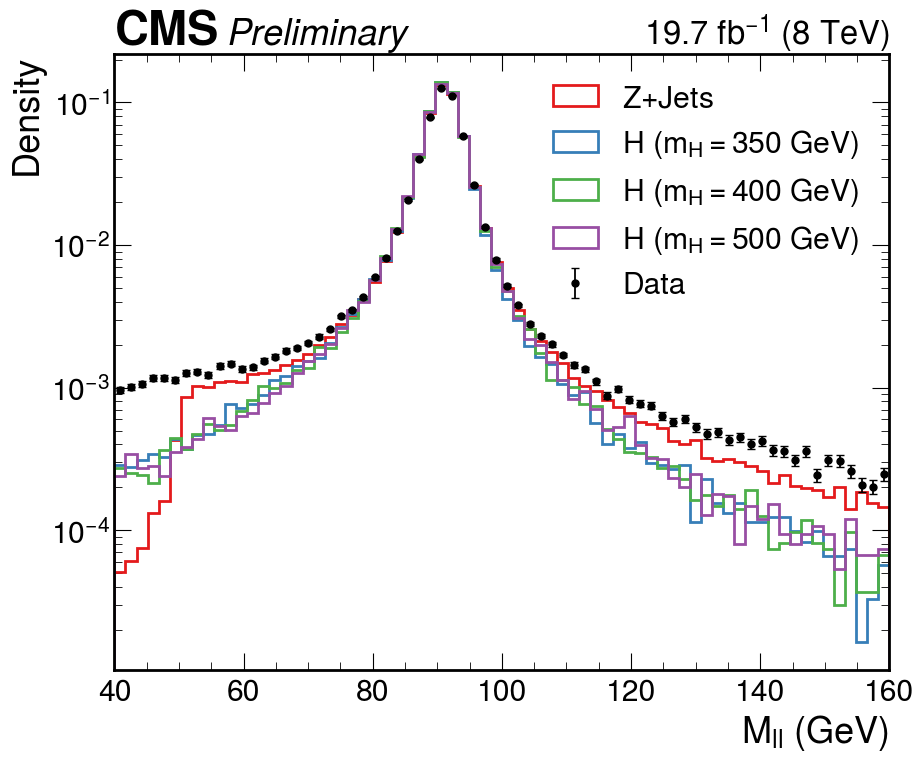

In [ ]:
fig, ax = compare_cms(
    var      = "Mll",
    datasets = {
        "ZJets"    : {"df": ZJets,    "label": r"$Z$+Jets",                       "lumi": lumi_zjets},
        "Higgs350" : {"df": Higgs350, "label": r"$H\ (m_H = 350\ \mathrm{GeV})$", "lumi": lumi_higgs350},
        "Higgs400" : {"df": Higgs400, "label": r"$H\ (m_H = 400\ \mathrm{GeV})$", "lumi": lumi_higgs400},
        "Higgs500" : {"df": Higgs500, "label": r"$H\ (m_H = 500\ \mathrm{GeV})$", "lumi": lumi_higgs500},
        "Data"     : {"df": Data,     "label": "Data",                            "type": "data"},
    },
    x_range  = (40, 160),
    bins     = 70,
    xl       = r"$M_{ll}$ (GeV)",
    density  = True,
    log      = True,
    lumi_ref = lumi_data,
    com      = 8,
    cms_label= "Preliminary",
)

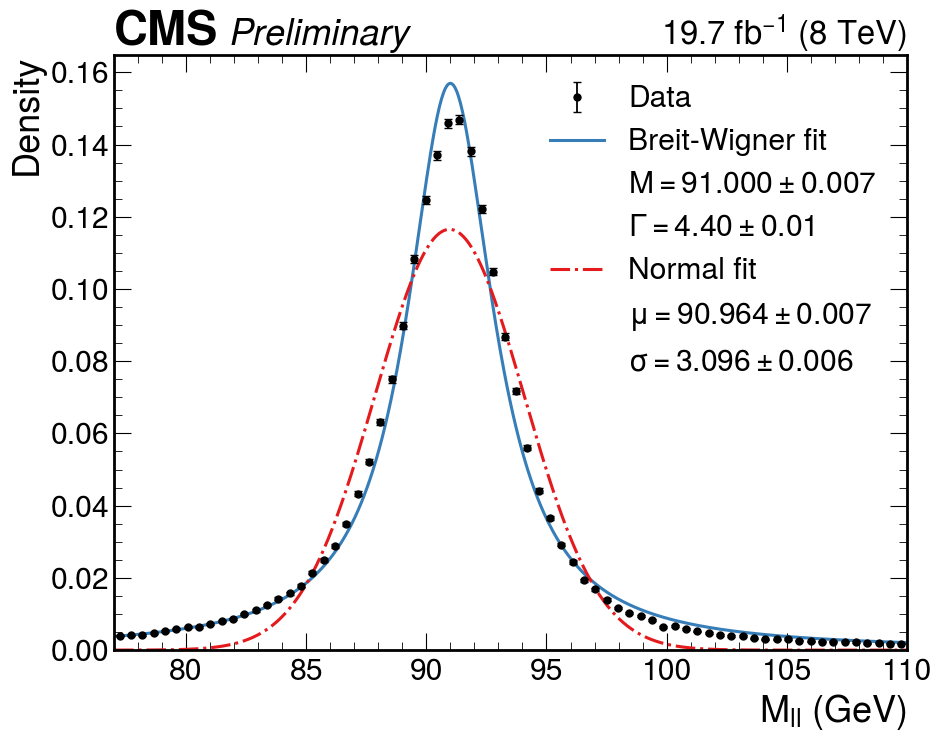

In [ ]:
fig, ax = fit_cms(
    var       = "Mll",
    df        = Data,
    x_range   = (77, 110),
    fit_range = (75, 110),
    bins      = 70,
    label     = r"Data",
    data_type = "data",
    xl        = r"$M_{ll}$ (GeV)",
    density   = True,
    com       = 8,
    lumi_ref  = lumi_data,
    cms_label = "Preliminary",
    figsize   = (10,8)
)

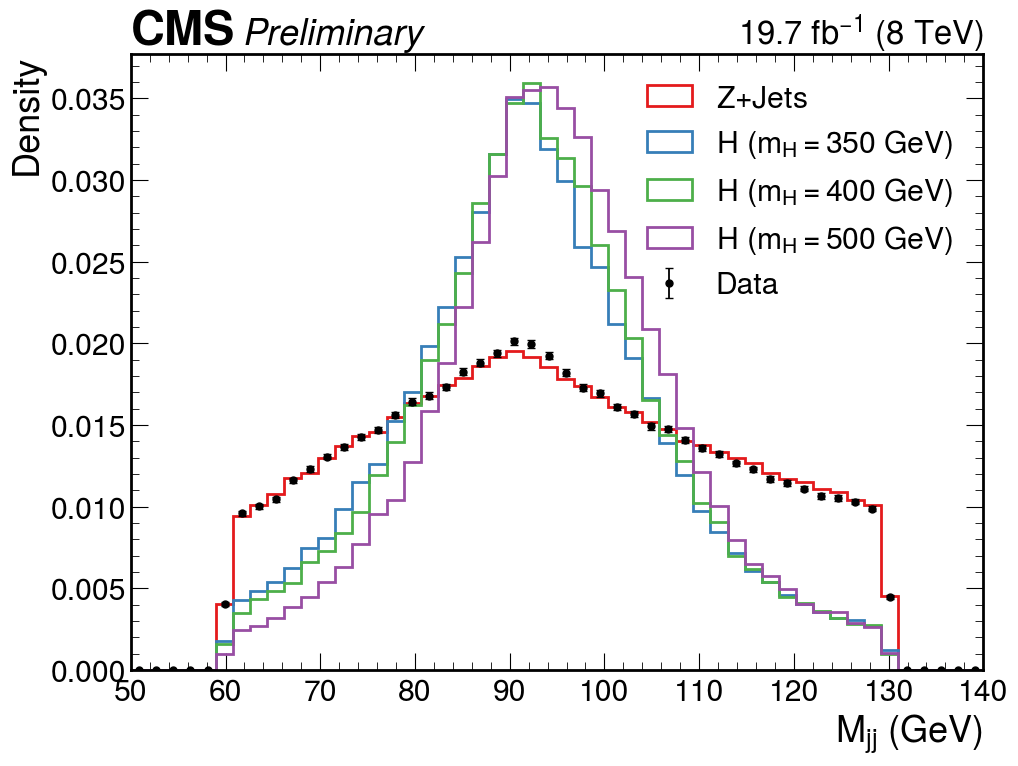

In [ ]:
fig, ax = compare_cms(
    var      = "Mjj",
    datasets = {
        "ZJets"    : {"df": ZJets,    "label": r"$Z$+Jets",                       "lumi": lumi_zjets},
        "Higgs350" : {"df": Higgs350, "label": r"$H\ (m_H = 350\ \mathrm{GeV})$", "lumi": lumi_higgs350},
        "Higgs400" : {"df": Higgs400, "label": r"$H\ (m_H = 400\ \mathrm{GeV})$", "lumi": lumi_higgs400},
        "Higgs500" : {"df": Higgs500, "label": r"$H\ (m_H = 500\ \mathrm{GeV})$", "lumi": lumi_higgs500},
        "Data"     : {"df": Data,     "label": "Data",                            "type": "data"},
    },
    x_range  = (50, 140),
    figsize  = (11,8),
    bins     = 50,
    xl       = r"$M_{jj}$ (GeV)",
    density  = True,
    lumi_ref = lumi_data,
    com      = 8,
    cms_label= "Preliminary",
)

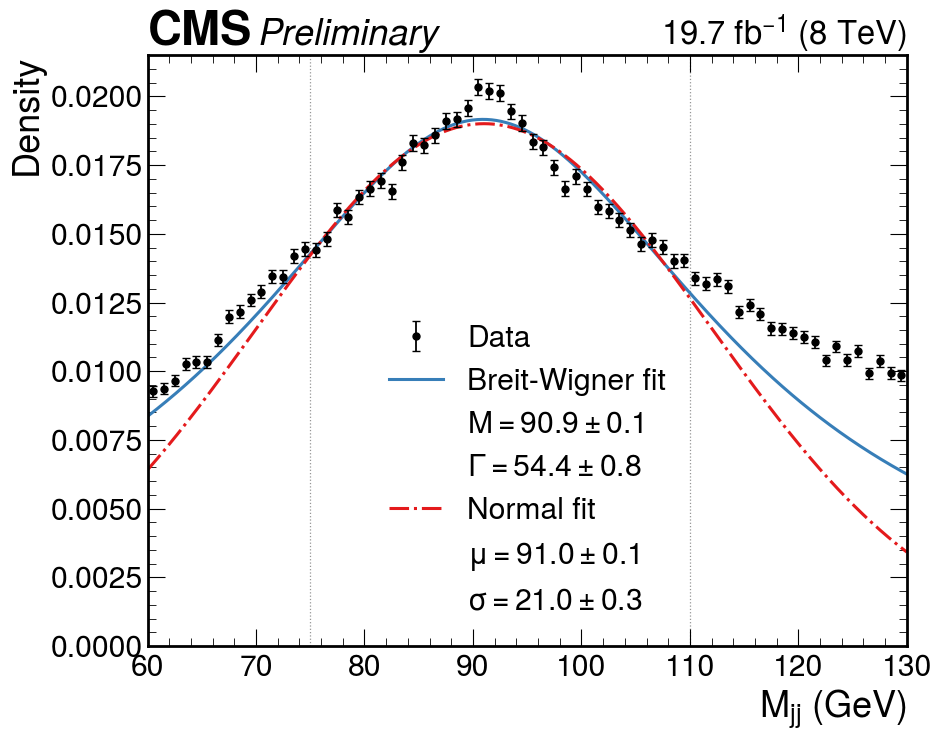

In [ ]:
fig, ax = fit_cms(
    var       = "Mjj",
    df        = Data,
    x_range   = (60, 130),
    fit_range = (75, 110),
    bins      = 70,
    label     = r"Data",
    data_type = "data",
    xl        = r"$M_{jj}$ (GeV)",
    density   = True,
    com       = 8,
    lumi_ref  = lumi_data,
    cms_label = "Preliminary"
)

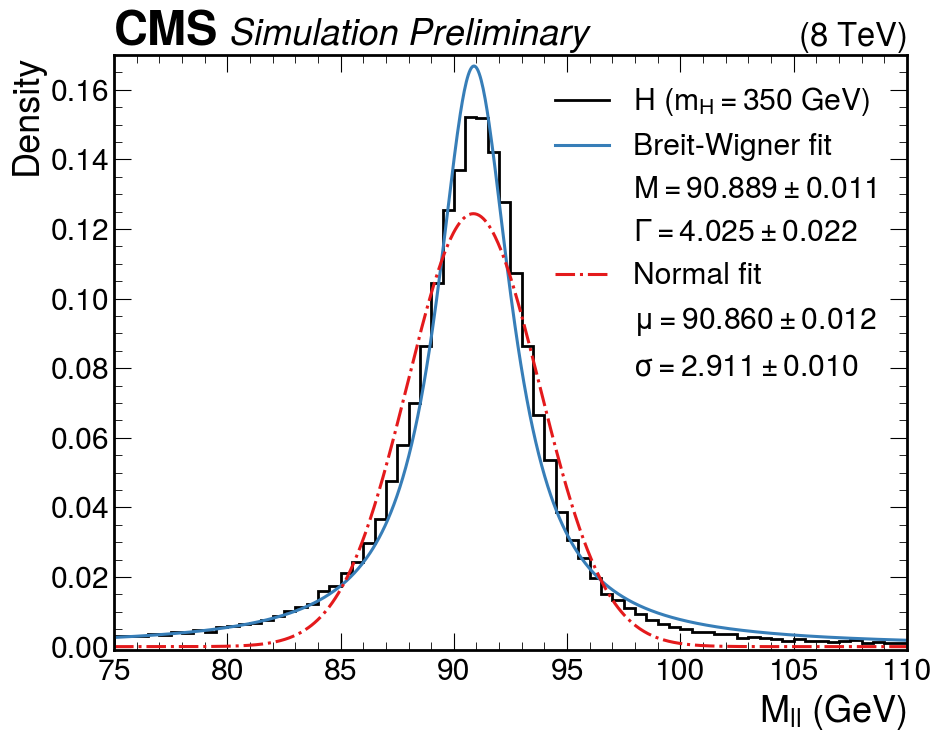

In [ ]:
fig, ax = fit_cms(
    var       = "Mll",
    df        = Higgs350,
    x_range   = (75, 110),
    ylim   = (-0.001, 0.17),
    fit_range = (75, 110),
    bins      = 70,
    label     = r"H ($m_H=350$ GeV)",
    data_type = "mc",
    xl        = r"$M_{ll}$ (GeV)",
    density   = True,
    com       = 8,
    lumi_ref  = lumi_data,
    cms_label = "Preliminary"
)

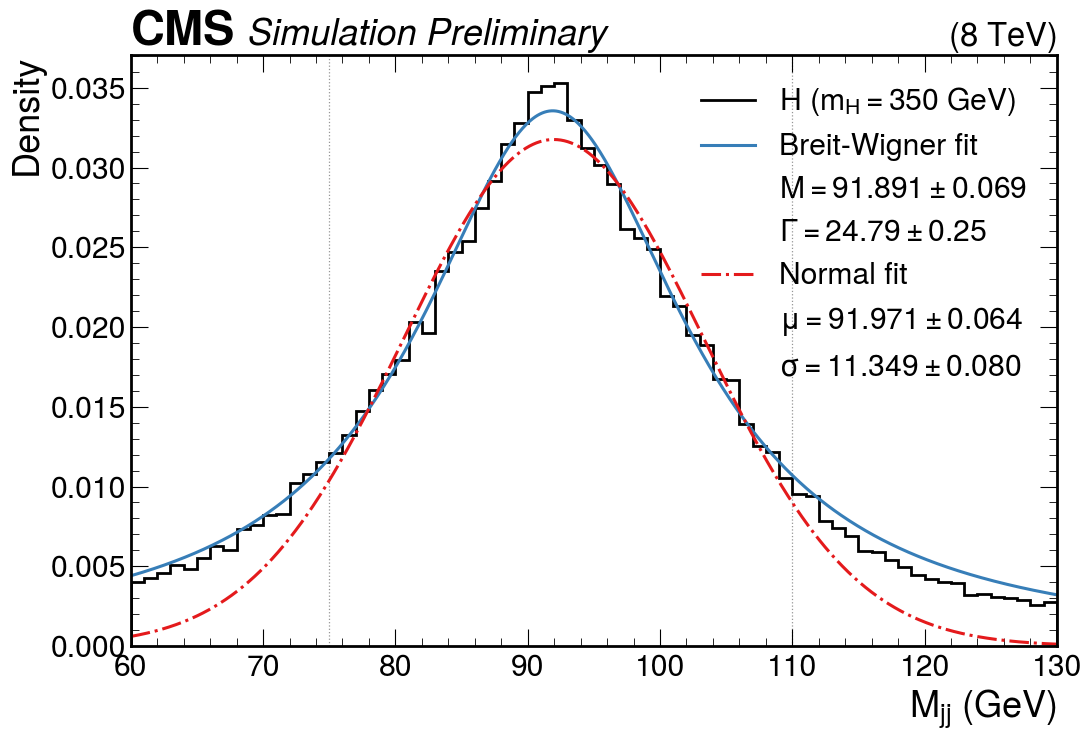

In [ ]:
fig, ax = fit_cms(
    var       = "Mjj",
    df        = Higgs350,
    x_range   = (60, 130),
    fit_range = (75, 110),
    bins      = 70,
    label     = r"H ($m_H=350$ GeV)",
    data_type = "mc",
    xl        = r"$M_{jj}$ (GeV)",
    density   = True,
    com       = 8,
    lumi_ref  = lumi_data,
    cms_label = "Preliminary",
    figsize   = (11.5,8)
)

## Cutting strategy

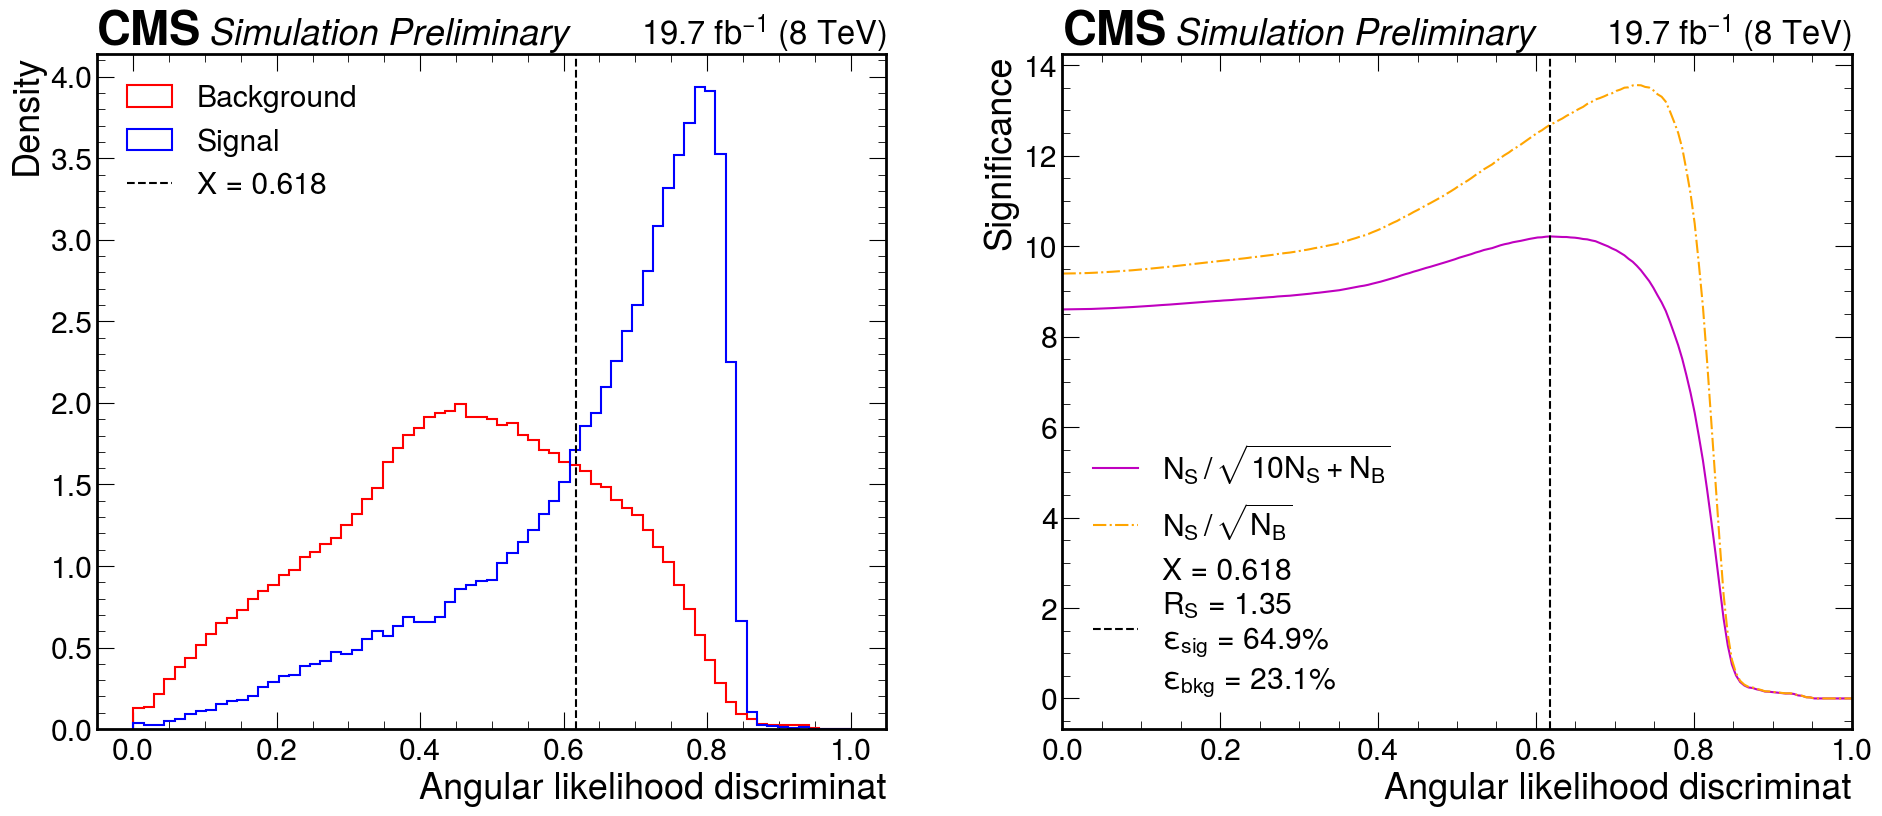

In [ ]:
result_ld = find_cut(Higgs350, ZJets, "ld", lumi_higgs350, lumi_zjets, lumi_data)
plot_cut(sgn=Higgs350, bkg=ZJets, var="ld", result=result_ld, x_range=[0, 1], xl=r"Angular likelihood discriminat")

In [ ]:
def find_cut(sgn, bkg, var, lumi_sgn, lumi_bkg, lumi_ref, n_scan=500, minN=10):
    """
    Find the optimal one-sided cut X that maximises weighted significance.
    Keeps events with value > X.

    Parameters
    ----------
    sgn, bkg   : pd.DataFrame   Signal and background samples.
    var        : str            Column to cut on.
    lumi_sgn   : float          MC luminosity of the signal sample in fb⁻¹.
    lumi_bkg   : float          MC luminosity of the background sample in fb⁻¹.
    lumi_ref   : float          Reference (data) luminosity in fb⁻¹.
    n_scan     : int            Number of cut values to scan.
    minN       : float          Minimum total scaled events to compute
                                the weighted significance.

    Returns
    -------
    dict with keys:
        best_cut, total_significance, scaled_significance, significance,
        cuts, S_scaled_values, S_values, eff_signal, eff_bkg
    """
    s_vals = sgn[var].values
    b_vals = bkg[var].values

    w_s = lumi_ref / lumi_sgn
    w_b = lumi_ref / lumi_bkg

    N_S_tot = len(s_vals) * w_s
    N_B_tot = len(b_vals) * w_b

    lo   = min(s_vals.min(), b_vals.min())
    hi   = max(s_vals.max(), b_vals.max())
    cuts = np.linspace(lo, hi, n_scan)

    S_values        = np.full(n_scan, np.nan)
    S_scaled_values = np.full(n_scan, np.nan)

    for i, X in enumerate(cuts):
        N_S = np.sum(s_vals > X) * w_s
        N_B = np.sum(b_vals > X) * w_b

        if (N_S + N_B) >= minN:
            S_scaled_values[i] = N_S / np.sqrt(10 * N_S + N_B)
        if N_B > 0:
            S_values[i] = N_S / np.sqrt(N_B)

    best_idx = np.nanargmax(S_scaled_values)
    best_cut = cuts[best_idx]

    return {
        "best_cut"           : best_cut,
        "total_significance" : N_S_tot / np.sqrt(N_B_tot),
        "scaled_significance": S_scaled_values[best_idx],
        "significance"       : S_values[best_idx],
        "cuts"               : cuts,
        "S_scaled_values"    : S_scaled_values,
        "S_values"           : S_values,
        "eff_signal"         : np.sum(s_vals > best_cut) / len(s_vals),
        "eff_bkg"            : np.sum(b_vals > best_cut) / len(b_vals),
    }


def find_centered_cut(sgn, bkg, var, lumi_sgn, lumi_bkg, lumi_ref,
                      M, n_scan=500, minN=10):
    """
    Find the optimal symmetric window [M − R*, M + R*] that maximises
    weighted significance.  Keeps events with |value − M| ≤ R.

    Parameters
    ----------
    sgn, bkg   : pd.DataFrame   Signal and background samples.
    var        : str            Column to cut on.
    lumi_sgn   : float          MC luminosity of the signal sample in fb⁻¹.
    lumi_bkg   : float          MC luminosity of the background sample in fb⁻¹.
    lumi_ref   : float          Reference (data) luminosity in fb⁻¹.
    M          : float          Centre of the window (e.g. nominal resonance mass).
    n_scan     : int            Number of radii to scan.
    minN       : float          Minimum total scaled events to compute
                                the weighted significance.

    Returns
    -------
    dict with keys:
        best_R, best_window, total_significance, scaled_significance,
        significance, radii, S_scaled_values, S_values, eff_signal, eff_bkg
    """
    s_vals = sgn[var].values
    b_vals = bkg[var].values

    w_s = lumi_ref / lumi_sgn
    w_b = lumi_ref / lumi_bkg

    N_S_tot = len(s_vals) * w_s
    N_B_tot = len(b_vals) * w_b

    # Maximum useful radius: reach the furthest data point from M
    R_max = max(
        abs(s_vals - M).max(),
        abs(b_vals - M).max(),
    )
    radii = np.linspace(0, R_max, n_scan + 1)[1:]   # exclude R = 0

    S_values        = np.full(n_scan, np.nan)
    S_scaled_values = np.full(n_scan, np.nan)

    for i, R in enumerate(radii):
        N_S = np.sum(np.abs(s_vals - M) <= R) * w_s
        N_B = np.sum(np.abs(b_vals - M) <= R) * w_b

        if (N_S + N_B) >= minN:
            S_scaled_values[i] = N_S / np.sqrt(10 * N_S + N_B)
        if N_B > 0:
            S_values[i] = N_S / np.sqrt(N_B)

    best_idx = np.nanargmax(S_scaled_values)
    best_R   = radii[best_idx]

    return {
        "best_R"             : best_R,
        "best_window"        : (M - best_R, M + best_R),
        "center"             : M,
        "total_significance" : N_S_tot / np.sqrt(N_B_tot),
        "scaled_significance": S_scaled_values[best_idx],
        "significance"       : S_values[best_idx],
        "radii"              : radii,
        "S_scaled_values"    : S_scaled_values,
        "S_values"           : S_values,
        "eff_signal"         : np.sum(np.abs(s_vals - M) <= best_R) / len(s_vals),
        "eff_bkg"            : np.sum(np.abs(b_vals - M) <= best_R) / len(b_vals),
    }


# ── Cut diagnostic plots ──────────────────────────────────────────────────────

def _cut_axes_style(ax, xl, yl):
    """Shared axis cosmetics for cut plots."""
    ax.set_xlabel(xl, ha="right", x=1.0)
    ax.set_ylabel(yl, ha="right", y=1.0)
    ax.legend(loc="upper right", frameon=False)


def plot_cut(sgn, bkg, var, result, lumi_ref, com=13,
             x_range=None, xl=None, year=None):
    """
    Two-panel diagnostic for ``find_cut``.
    Left  : signal/background density distributions with the optimal cut.
    Right : significance curves vs cut value.

    Parameters
    ----------
    sgn, bkg  : pd.DataFrame
    var       : str
    result    : dict          Output of ``find_cut``.
    lumi_ref  : float         Reference luminosity in fb⁻¹ (for CMS header).
    com       : float         Centre-of-mass energy in TeV.
    x_range   : (float,float) Optional x-axis range for both panels.
    xl        : str           X-axis label.
    year      : str           Data-taking year for CMS header.
    """
    hep.style.use("CMS")

    s_vals = sgn[var].values
    b_vals = bkg[var].values
    X_best = result["best_cut"]
    xl     = xl or var

    if x_range:
        bin_edges = np.linspace(x_range[0], x_range[1], 70)
    else:
        bin_edges = np.linspace(
            min(s_vals.min(), b_vals.min()),
            max(s_vals.max(), b_vals.max()), 60,
        )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(19, 8))
    fig.tight_layout(w_pad=3)

    # ── Left: distributions ───────────────────────────────────────────────────
    ax1.hist(b_vals, bins=bin_edges, density=True, histtype="step",
             color=_CMP_COLORS[0], linewidth=2.0, label="Background")
    ax1.hist(s_vals, bins=bin_edges, density=True, histtype="step",
             color=_CMP_COLORS[1], linewidth=2.0, label="Signal")
    ax1.axvline(X_best, color="black", lw=1.5, ls="--",
                label=rf"$X^* = {X_best:.3g}$" )
    # Shade the rejected region
    ax1.axvspan(bin_edges[0], X_best, alpha=0.08, color="black", zorder=0)

    hep.cms.label("Simulation Preliminary", data=False,
                  com=com, year=year, ax=ax1)
    _cut_axes_style(ax1, xl, "Density")

    # ── Right: significance curves ────────────────────────────────────────────
    ax2.plot(result["cuts"], result["S_scaled_values"],
             color=_CMP_COLORS[1], lw=2.0,
             label=r"$N_S\,/\,\sqrt{10N_S + N_B}$" )
    ax2.plot(result["cuts"], result["S_values"],
             color=_CMP_COLORS[0], lw=2.0, ls="-.",
             label=r"$N_S\,/\,\sqrt{N_B}$" )
    ax2.axvline(X_best, color="black", lw=1.5, ls="--",
                label=(rf"$X^* = {X_best:.3g}$"                                           + "\n"
     + rf"$\varepsilon_S = {result['eff_signal']*100:.1f}\%$"              + "\n"
     + rf"$\varepsilon_B = {result['eff_bkg']*100:.1f}\%$"))

    if x_range:
        ax2.set_xlim(x_range)

    hep.cms.label("Simulation Preliminary", data=False,
                  com=com, year=year, ax=ax2)
    _cut_axes_style(ax2, xl, "Significance")

    fig.align_ylabels()
    return fig, (ax1, ax2)


def plot_centered_cut(sgn, bkg, var, result, lumi_ref, com=13,
                      x_range=None, xl=None, year=None):
    """
    Two-panel diagnostic for ``find_centered_cut``.
    Left  : signal/background density distributions with the optimal window
            [M − R*, M + R*] shaded.
    Right : significance curves vs radius R.

    Parameters
    ----------
    sgn, bkg  : pd.DataFrame
    var       : str
    result    : dict          Output of ``find_centered_cut``.
    lumi_ref  : float         Reference luminosity in fb⁻¹ (for CMS header).
    com       : float         Centre-of-mass energy in TeV.
    x_range   : (float,float) Optional x-axis range for the left panel.
    xl        : str           X-axis label.
    year      : str           Data-taking year for CMS header.
    """
    hep.style.use("CMS")

    s_vals  = sgn[var].values
    b_vals  = bkg[var].values
    M       = result["center"]
    R_best  = result["best_R"]
    win_lo, win_hi = result["best_window"]
    xl      = xl or var

    if x_range:
        bin_edges = np.linspace(x_range[0], x_range[1], 70)
    else:
        bin_edges = np.linspace(
            min(s_vals.min(), b_vals.min()),
            max(s_vals.max(), b_vals.max()), 60,
        )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(19, 8))
    fig.tight_layout(w_pad=3)

    # ── Left: distributions ───────────────────────────────────────────────────
    ax1.hist(b_vals, bins=bin_edges, density=True, histtype="step",
             color=_CMP_COLORS[0], linewidth=2.0, label="Background")
    ax1.hist(s_vals, bins=bin_edges, density=True, histtype="step",
             color=_CMP_COLORS[1], linewidth=2.0, label="Signal")

    # Shade the accepted window
    ax1.axvspan(win_lo, win_hi, alpha=0.10, color=_CMP_COLORS[1], zorder=0)

    # Mark centre and window edges
    ax1.axvline(M,      color="black",        lw=1.5, ls="-",
                label=rf"$M = {M:.3g}$" )
    ax1.axvline(win_lo, color="black",        lw=1.2, ls="--",
                label=rf"$R^* = {R_best:.3g}$" )
    ax1.axvline(win_hi, color="black",        lw=1.2, ls="--")

    hep.cms.label("Simulation Preliminary", data=False,
                  com=com, year=year, ax=ax1)
    _cut_axes_style(ax1, xl, "Density")

    # ── Right: significance vs radius ─────────────────────────────────────────
    ax2.plot(result["radii"], result["S_scaled_values"],
             color=_CMP_COLORS[1], lw=2.0,
             label=r"$N_S\,/\,\sqrt{10N_S + N_B}$" )
    ax2.plot(result["radii"], result["S_values"],
             color=_CMP_COLORS[0], lw=2.0, ls="-.",
             label=r"$N_S\,/\,\sqrt{N_B}$" )
    ax2.axvline(R_best, color="black", lw=1.5, ls="--",
                label=(rf"$R^* = {R_best:.3g}$"                                           + "\n"
     + rf"$\varepsilon_S = {result['eff_signal']*100:.1f}\%$"              + "\n"
     + rf"$\varepsilon_B = {result['eff_bkg']  *100:.1f}\%$"))

    hep.cms.label("Simulation Preliminary", data=False,
                  com=com, year=year, ax=ax2)
    _cut_axes_style(ax2, "Radius $R$", "Significance")

    fig.align_ylabels()
    return fig, (ax1, ax2)

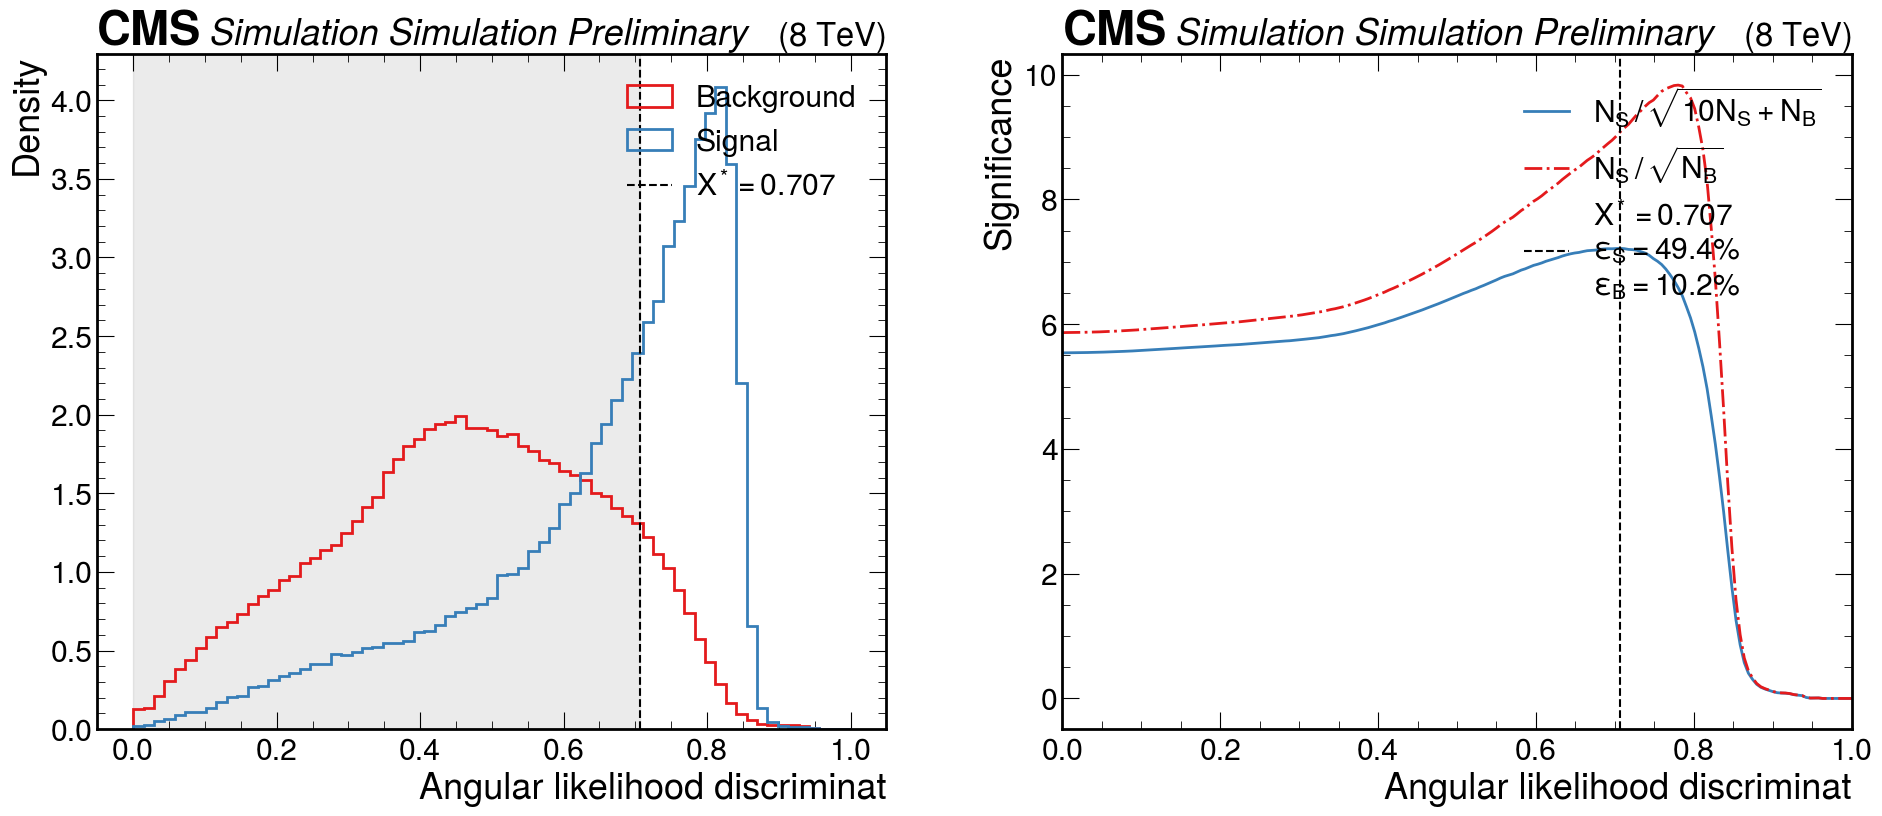

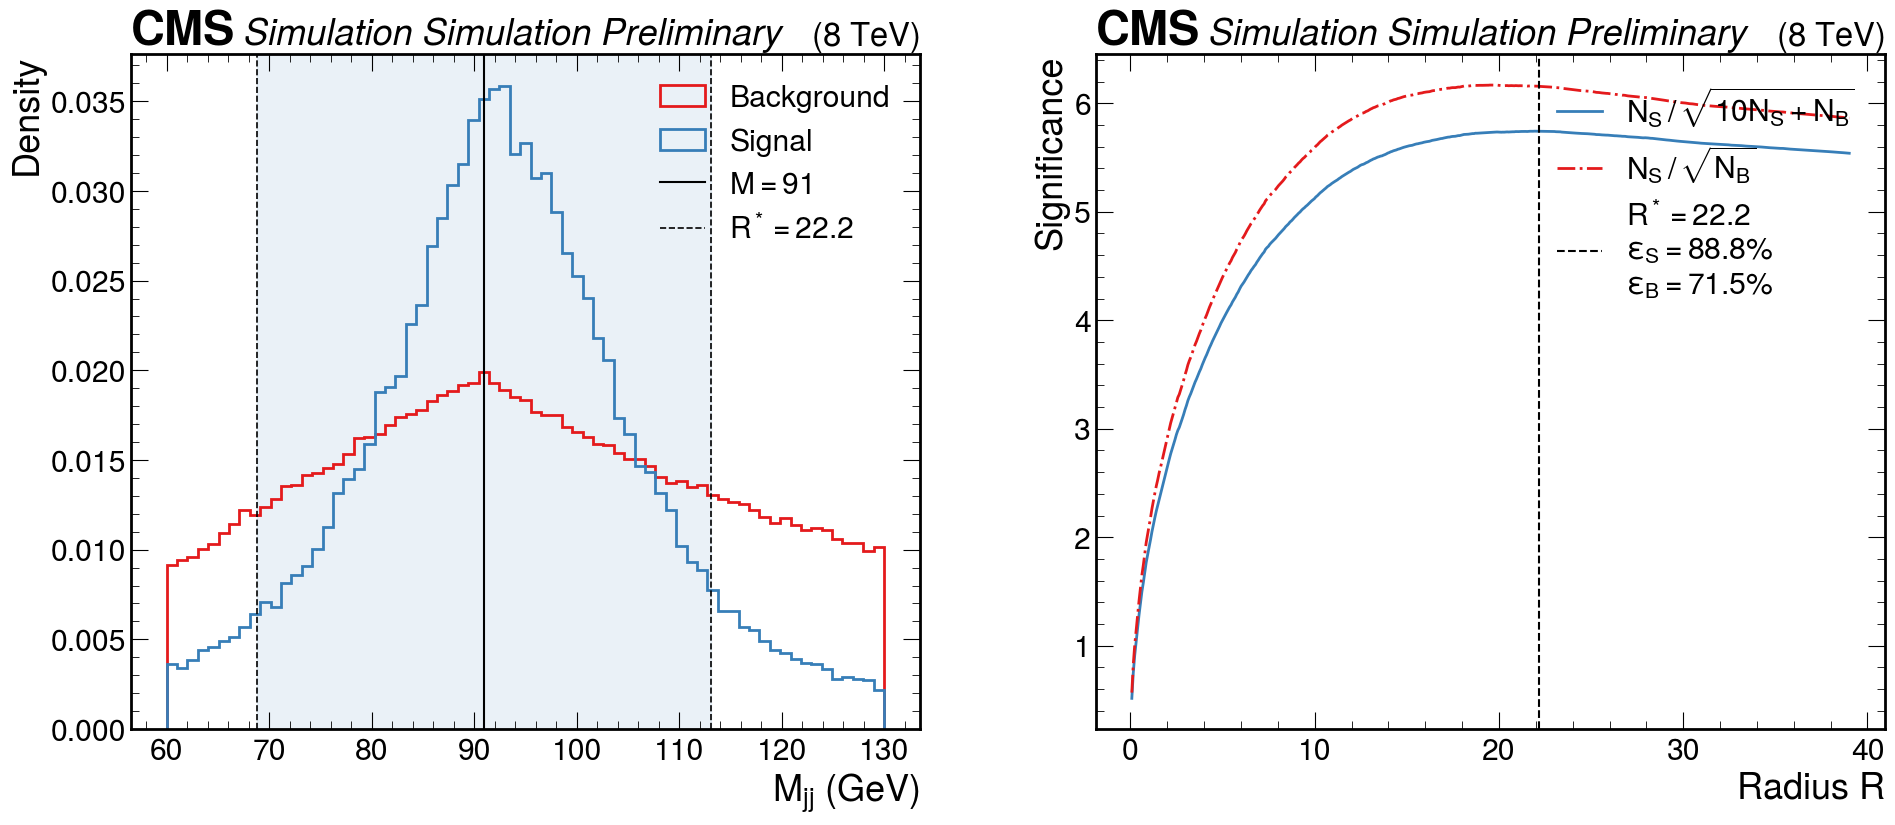

In [ ]:
# One-sided cut on leading lepton pT
result_pt = find_cut(
    Higgs400, ZJets, "ld",
    lumi_higgs400, lumi_zjets, lumi_data,
)
fig, axes = plot_cut(
    Higgs400, ZJets, "ld", result_pt,
    lumi_ref = lumi_data,
    com      = 8,
    x_range  = (0, 1),
    xl       = r"Angular likelihood discriminat"
)

# Symmetric window around the Higgs mass peak
result_m = find_centered_cut(
    Higgs400, ZJets, "Mjj",
    lumi_higgs400, lumi_zjets, lumi_data,
    M = 91,
)
fig, axes = plot_centered_cut(
    Higgs400, ZJets, "Mjj", result_m,
    lumi_ref = lumi_data,
    com      = 8,
    x_range  = (60, 130),
    xl       = r"$M_{jj}$ (GeV)"
)

## Real Data Analysis

Directory already exists: /content/drive/MyDrive/ExP-CMS/Figures


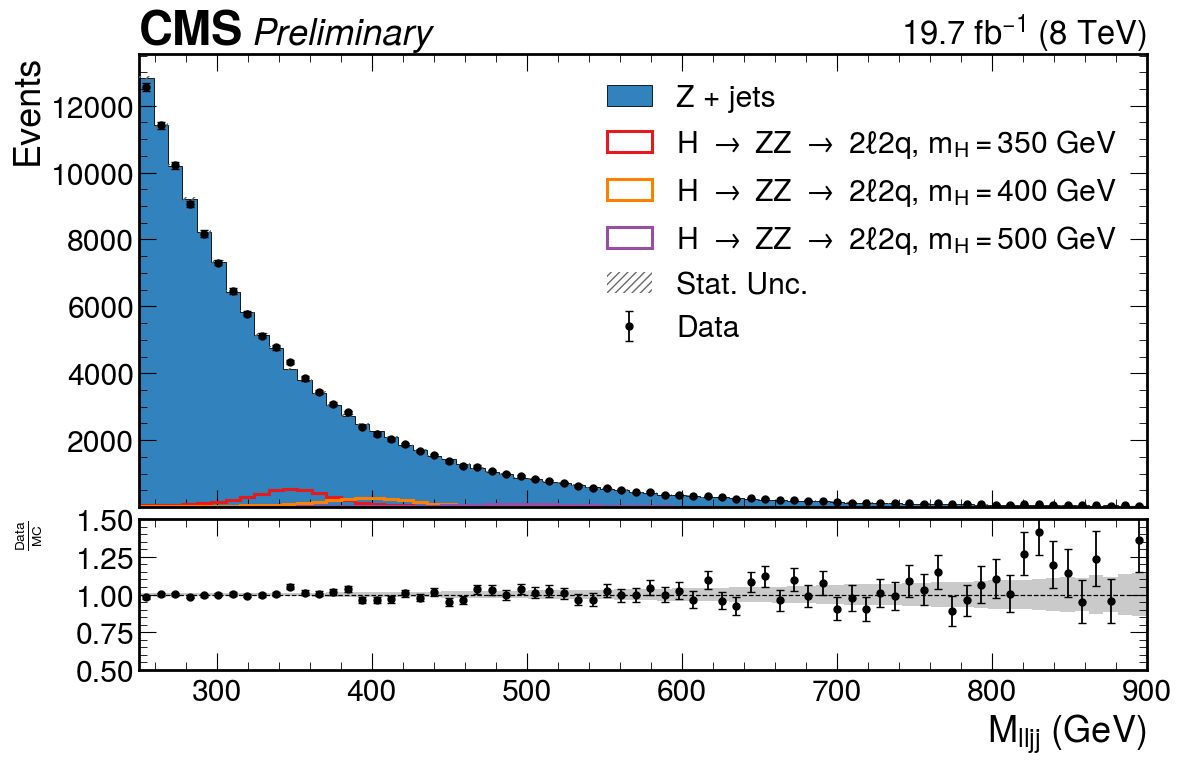

In [10]:
mc = {
    "zjets": {
        "df":    ZJets,
        "label": r"Z + jets",
        "lumi":  lumi_zjets,
        "type":  "bkg",
    },
    "higgs350": {
        "df":    Higgs350,
        "label": r"H $\to$ ZZ $\to$ 2$\ell$2q, $m_H = 350$ GeV",
        "lumi":  lumi_higgs350,
        "type":  "sig",
    },
    "higgs400": {
        "df":    Higgs400,
        "label": r"H $\to$ ZZ $\to$ 2$\ell$2q, $m_H = 400$ GeV",
        "lumi":  lumi_higgs400,
        "type":  "sig",
    },
    "higgs500": {
        "df":    Higgs500,
        "label": r"H $\to$ ZZ $\to$ 2$\ell$2q, $m_H = 500$ GeV",
        "lumi":  lumi_higgs500,
        "type":  "sig",
    },
}

fig, ax, ax_ratio = plot_cms(
    df        = Data,
    var       = "Mlljj",
    x_range   = (250, 900),
    bins      = 70,
    log       = False,
    figsize   = (13,8),
    xl        = r"$M_{lljj}$ (GeV)",
    mc        = mc,
    lumi_data = lumi_data,
    cms_label = "Preliminary",
    com       = 8,
    ratio     = True,
    ylim      = (1, None),
)

figures_dir = "/content/drive/MyDrive/ExP-CMS/Figures"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Created directory: {figures_dir}")
else:
    print(f"Directory already exists: {figures_dir}")


plt.savefig(os.path.join(figures_dir, "Mlljj_Data.pdf"), bbox_inches="tight")
plt.show()

In [14]:
result_ld = find_cut(Higgs350, ZJets, "ld", lumi_higgs350, lumi_zjets, lumi_data)
Xld = result_ld['best_cut']

ZJets_ld = ZJets[ZJets['ld'] > Xld]
Higgs350_ld = Higgs350[Higgs350['ld'] > Xld]
Higgs400_ld = Higgs400[Higgs400['ld'] > Xld]
Higgs500_ld = Higgs500[Higgs500['ld'] > Xld]
Data_ld = Data[Data['ld'] > Xld]

Directory already exists: /content/drive/MyDrive/ExP-CMS/Figures


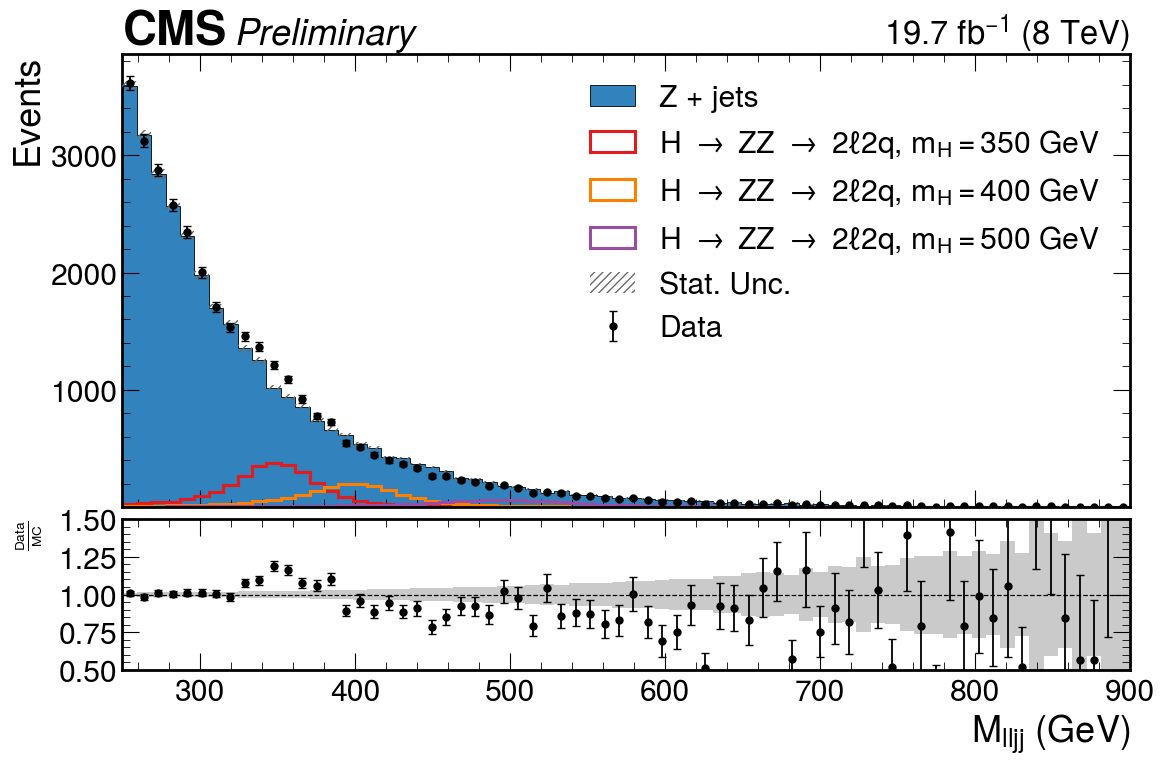

In [ ]:
mc = {
    "zjets": {
        "df":    ZJets_ld,
        "label": r"Z + jets",
        "lumi":  lumi_zjets,
        "type":  "bkg",
    },
    "higgs350": {
        "df":    Higgs350_ld,
        "label": r"H $\to$ ZZ $\to$ 2$\ell$2q, $m_H = 350$ GeV",
        "lumi":  lumi_higgs350,
        "type":  "sig",
    },
    "higgs400": {
        "df":    Higgs400_ld,
        "label": r"H $\to$ ZZ $\to$ 2$\ell$2q, $m_H = 400$ GeV",
        "lumi":  lumi_higgs400,
        "type":  "sig",
    },
    "higgs500": {
        "df":    Higgs500_ld,
        "label": r"H $\to$ ZZ $\to$ 2$\ell$2q, $m_H = 500$ GeV",
        "lumi":  lumi_higgs500,
        "type":  "sig",
    },
}

fig, ax, ax_ratio = plot_cms(
    df        = Data_ld,
    var       = "Mlljj",
    x_range   = (250, 900),
    bins      = 70,
    log       = False,
    figsize   = (13,8),
    xl        = r"$M_{lljj}$ (GeV)",
    mc        = mc,
    lumi_data = lumi_data,
    cms_label = "Preliminary",
    com       = 8,
    ratio     = True,
    ylim      = (1, None),
)

figures_dir = "/content/drive/MyDrive/ExP-CMS/Figures"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Created directory: {figures_dir}")
else:
    print(f"Directory already exists: {figures_dir}")


plt.savefig(os.path.join(figures_dir, "Mlljj_Data_ld.pdf"), bbox_inches="tight")
plt.show()

In [15]:
Mjj_min=75
Mjj_max=115

ZJets_ldMjj = ZJets_ld[(ZJets_ld['Mjj'] > Mjj_min) & (ZJets_ld['Mjj'] < Mjj_max)]
Higgs350_ldMjj = Higgs350_ld[(Higgs350_ld['Mjj'] > Mjj_min) & (Higgs350_ld['Mjj'] < Mjj_max)]
Higgs400_ldMjj = Higgs400_ld[(Higgs400_ld['Mjj'] > Mjj_min) & (Higgs400_ld['Mjj'] < Mjj_max)]
Higgs500_ldMjj = Higgs500_ld[(Higgs500_ld['Mjj'] > Mjj_min) & (Higgs500_ld['Mjj'] < Mjj_max)]
Data_ldMjj = Data_ld[(Data_ld['Mjj'] > Mjj_min) & (Data_ld['Mjj'] < Mjj_max)]

Directory already exists: /content/drive/MyDrive/ExP-CMS/Figures


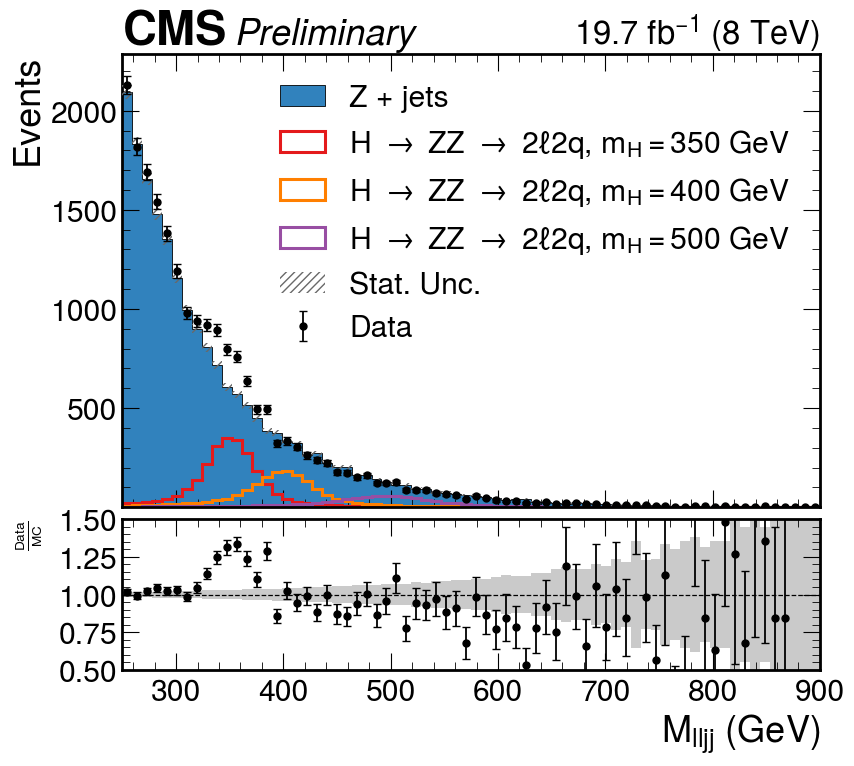

In [16]:
mc = {
    "zjets": {
        "df":    ZJets_ldMjj,
        "label": r"Z + jets",
        "lumi":  lumi_zjets,
        "type":  "bkg",
    },
    "higgs350": {
        "df":    Higgs350_ldMjj,
        "label": r"H $\to$ ZZ $\to$ 2$\ell$2q, $m_H = 350$ GeV",
        "lumi":  lumi_higgs350,
        "type":  "sig",
    },
    "higgs400": {
        "df":    Higgs400_ldMjj,
        "label": r"H $\to$ ZZ $\to$ 2$\ell$2q, $m_H = 400$ GeV",
        "lumi":  lumi_higgs400,
        "type":  "sig",
    },
    "higgs500": {
        "df":    Higgs500_ldMjj,
        "label": r"H $\to$ ZZ $\to$ 2$\ell$2q, $m_H = 500$ GeV",
        "lumi":  lumi_higgs500,
        "type":  "sig",
    },
}

fig, ax, ax_ratio = plot_cms(
    df        = Data_ldMjj,
    var       = "Mlljj",
    x_range   = (250, 900),
    bins      = 70,
    log       = False,
    figsize   = (9,8),
    xl        = r"$M_{lljj}$ (GeV)",
    mc        = mc,
    lumi_data = lumi_data,
    cms_label = "Preliminary",
    com       = 8,
    ratio     = True,
    ylim      = (1, None),
)

figures_dir = "/content/drive/MyDrive/ExP-CMS/Figures"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Created directory: {figures_dir}")
else:
    print(f"Directory already exists: {figures_dir}")


plt.savefig(os.path.join(figures_dir, "Mlljj_Data_ldMjj.pdf"), bbox_inches="tight")
plt.show()

In [56]:
import warnings

_FIT_TOTAL_COLOR = "black"
_FIT_BKG_COLOR   = "#e41a1c"   # CMS red
_FIT_SIG_COLOR   = "#984ea3"   # CMS blue


def _make_fit_models(x_lo: float, x_hi: float, bin_width: float):
    """
    Factory returning (total, bkg_only, sig_only) binned models where
    N_b and N_s are the integrated event yields within [x_lo, x_hi].
    Each model returns expected counts per bin (not density).
    """
    def _exp_norm(lam):
        # Normalisation of exp on [x_lo, x_hi]
        return (np.exp(-lam * x_lo) - np.exp(-lam * x_hi)) / lam

    def total(x, N_b, lam, N_s, mu, sigma):
        bkg = N_b * np.exp(-lam * x) / _exp_norm(lam)
        sig = N_s / (np.sqrt(2 * np.pi) * abs(sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
        return bin_width * (bkg + sig)

    def bkg_only(x, N_b, lam):
        return bin_width * N_b * np.exp(-lam * x) / _exp_norm(lam)

    def sig_only(x, N_s, mu, sigma):
        return bin_width * N_s / (np.sqrt(2 * np.pi) * abs(sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    return total, bkg_only, sig_only


def _significance_from_fit(N_s, N_b_win, sigma_Ns, sigma_N_b_win):
    """
    S = N_s / sqrt(N_b_win) where N_b_win is the background integrated
    over [mu-2sigma, mu+2sigma]. Errors propagated analytically.
    """
    if N_b_win <= 0 or N_s < 0:
        return np.nan, np.nan
    S     = N_s / np.sqrt(N_b_win)
    S_err = np.sqrt(
        (sigma_Ns          / np.sqrt(N_b_win))    ** 2 +   # ∂S/∂N_s
        (N_s * sigma_N_b_win / (2 * N_b_win**1.5)) ** 2    # ∂S/∂N_b_win
    )
    return S, S_err

def _bkg_in_window(N_b, lam, mu, sigma, fit_range, perr):
    """
    Integrate the exponential background over [mu - 2|sigma|, mu + 2|sigma|]
    (clamped to fit_range) and propagate errors on N_b and lam numerically.
    """
    x_lo, x_hi = fit_range
    lo = max(mu - 2 * abs(sigma), x_lo)
    hi = min(mu + 2 * abs(sigma), x_hi)

    def _integral(Nb, l):
        norm = (np.exp(-l * x_lo) - np.exp(-l * x_hi)) / l
        return Nb * (np.exp(-l * lo) - np.exp(-l * hi)) / l / norm

    N_b_win = _integral(N_b, lam)

    # Numerical partial derivatives
    eps_Nb  = N_b  * 1e-6
    eps_lam = lam  * 1e-6
    dNb_win_dNb  = (_integral(N_b + eps_Nb,  lam)         - _integral(N_b - eps_Nb,  lam))         / (2 * eps_Nb)
    dNb_win_dlam = (_integral(N_b,           lam + eps_lam) - _integral(N_b,         lam - eps_lam)) / (2 * eps_lam)

    sigma_N_b_win = np.sqrt(
        (dNb_win_dNb  * perr[0]) ** 2 +   # from σ_Nb
        (dNb_win_dlam * perr[1]) ** 2      # from σ_lam
    )
    return N_b_win, sigma_N_b_win


def plot_cms_fit(
    df,
    var: str,
    x_range: tuple[float, float],
    bins: int,
    fit_range: Optional[tuple[float, float]] = None,
    xl: Optional[str] = None,
    log: bool = False,
    ylim: Optional[tuple[float, float]] = None,
    mc: Optional[dict] = None,
    lumi_data: Optional[float] = None,
    cms_label: str = "Preliminary",
    com: float = 13,
    ratio: bool = True,
    figsize: Optional[tuple[float, float]] = None,
    yl: str = "Events",
    year: Optional[str] = None,
    fit_components: bool = True,
    fit_unit: str = "",
    p0: Optional[dict] = None,
) -> tuple:
    """
    CMS-style discovery plot: stacked MC backgrounds, signal hypotheses,
    data points, and an Exp + Gauss fit to the data.

    Extends ``plot_cms`` with:

    * **Total fit** (Exp + Gauss) — solid black curve.
    * **Background component** (Exp only) — CMS-red dashed, when ``fit_components=True``.
    * **Signal component** (Gauss only) — CMS-blue dash-dot, when ``fit_components=True``.
    * **Annotation box** — μ, σ, N_s, N_b, and significance in σ.
    * **Pull panel** — (Data − Bkg fit) / √(Bkg fit) per bin with ±1σ / ±2σ
      colour bands (green / gold).  Falls back to a Data/MC ratio panel if
      the fit does not converge.

    Parameters
    ----------
    df : pd.DataFrame
        Observed data.
    var : str
        Column to histogram and fit.
    x_range : (float, float)
        Full (x_min, x_max) of the histogram.
    bins : int
        Number of equal-width bins.
    fit_range : (float, float), optional
        Sub-range used for the fit.  Defaults to ``x_range``.
        Vertical dotted guide lines mark the boundaries when different.
        Fit curves are extrapolated over the full ``x_range``.
    xl : str, optional
        X-axis label.
    log : bool
        Logarithmic y-axis.
    ylim : (float, float), optional
        Override y-axis limits.
    mc : dict, optional
        Monte Carlo processes (same structure as ``plot_cms``)::

            mc = {
                "key": {
                    "df"    : pd.DataFrame,
                    "label" : str,
                    "lumi"  : float,
                    "type"  : "bkg" | "sig",   # default "bkg"
                    "color" : str,             # optional
                },
            }

    lumi_data : float, optional
        Reference luminosity in fb⁻¹.
    cms_label : str
        Text next to the CMS logo.
    com : float
        Centre-of-mass energy in TeV.
    ratio : bool
        Draw the pull / ratio panel below the main plot.
    figsize : (float, float), optional
        Override figure size.
    yl : str
        Y-axis label (default ``"Events"``).
    year : str, optional
        Data-taking year shown in the header.
    fit_components : bool
        Draw the background-only and signal-only components separately.
    fit_unit : str
        Unit string appended to μ and σ in the annotation (e.g. ``"GeV"``).
    p0 : dict, optional
        Initial guesses for the fit.
        Keys: ``"N_b"``, ``"lam"``, ``"N_s"``, ``"mu"``, ``"sigma"``.

    Returns
    -------
    (fig, ax)            when ``ratio=False``.
    (fig, ax, ax_pull)   when ``ratio=True``.

    Notes
    -----
    * The fit model is a binned Exp + Gauss where N_b and N_s are the
      integrated event yields within ``fit_range``.
    * Zero-count bins are excluded from the fit.
    * Save with ``fig.savefig(..., bbox_inches='tight')``.
    """
    hep.style.use("CMS")

    fit_range = fit_range or x_range
    xl        = xl or var

    # ── Binning ───────────────────────────────────────────────────────────────
    bin_edges   = np.linspace(x_range[0], x_range[1], bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]

    # ── Parse MC entries ──────────────────────────────────────────────────────
    bkg_entries, sig_entries = [], []
    n_bkg = n_sig = 0

    if mc:
        for key, info in mc.items():
            entry = {**info}
            etype = entry.get("type", "bkg")
            if "color" not in entry:
                entry["color"] = (_BKG_COLORS[n_bkg % len(_BKG_COLORS)] if etype == "bkg"
                                  else _SIG_COLORS[n_sig % len(_SIG_COLORS)])
            scale            = (lumi_data / entry["lumi"]) if (lumi_data and entry.get("lumi")) else 1.0
            raw, _           = np.histogram(entry["df"][var], bins=bin_edges)
            entry["counts"]  = raw * scale
            entry["errors"]  = np.sqrt(raw) * scale
            entry["weights"] = np.full(len(entry["df"]), scale)
            if etype == "bkg":
                bkg_entries.append(entry); n_bkg += 1
            else:
                sig_entries.append(entry); n_sig += 1

    has_bkg = bool(bkg_entries)
    if has_bkg:
        total_bkg     = np.sum([e["counts"] for e in bkg_entries], axis=0)
        total_bkg_err = np.sqrt(np.sum([e["errors"] ** 2 for e in bkg_entries], axis=0))

    # ── Data histogram ────────────────────────────────────────────────────────
    counts_data, _ = np.histogram(df[var], bins=bin_edges)
    errors_data    = np.sqrt(counts_data)

    # ── Figure layout ─────────────────────────────────────────────────────────
    show_pull = ratio
    if figsize is None:
        figsize = (10, 11) if show_pull else (10, 8)

    if show_pull:
        fig, (ax, ax_pull) = plt.subplots(
            2, 1, figsize=figsize,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.04},
            sharex=True,
        )
    else:
        fig, ax = plt.subplots(figsize=figsize)
        ax_pull = None

    # ── Stacked MC backgrounds ────────────────────────────────────────────────
    if has_bkg:
        ax.hist(
            [e["df"][var] for e in bkg_entries],
            bins=bin_edges,
            weights=[e["weights"] for e in bkg_entries],
            stacked=True, histtype="stepfilled",
            color=[e["color"] for e in bkg_entries],
            label=[e["label"] for e in bkg_entries],
            linewidth=0.6, edgecolor="black",
        )
        ax.bar(
            bin_centers, 2 * total_bkg_err,
            bottom=total_bkg - total_bkg_err,
            width=bin_width, fill=False,
            edgecolor="dimgrey", hatch="////",
            linewidth=0, label="Stat. Unc.", zorder=3,
        )

    # ── MC signal hypotheses (step) ───────────────────────────────────────────
    for entry in sig_entries:
        ax.hist(
            entry["df"][var], bins=bin_edges,
            weights=entry["weights"],
            histtype="step", color=entry["color"],
            label=entry["label"], linewidth=2.2,
        )

    # ── Data points ───────────────────────────────────────────────────────────
    ax.errorbar(
        bin_centers, counts_data, yerr=errors_data,
        fmt="o", color="black", markersize=5,
        capsize=3, elinewidth=1.3, label="Data", zorder=5,
    )

    # ── Fit ───────────────────────────────────────────────────────────────────
    fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1])
    valid    = fit_mask & (counts_data > 0)
    xf       = bin_centers[valid]
    yf       = counts_data[valid].astype(float)
    sf       = errors_data[valid]

    total_model, bkg_model, sig_model = _make_fit_models(fit_range[0], fit_range[1], bin_width)
    x_curve = np.linspace(x_range[0], x_range[1], 800)

    fit_ok = False
    popt = perr = None

    if len(xf) >= 5:
        peak_i = np.argmax(yf)
        _mu0   = p0.get("mu",    xf[peak_i])                                          if p0 else xf[peak_i]
        _sig0  = p0.get("sigma", (fit_range[1] - fit_range[0]) / 6)                   if p0 else (fit_range[1] - fit_range[0]) / 6
        _Ns0   = p0.get("N_s",   yf[peak_i] * _sig0 * np.sqrt(2 * np.pi) / bin_width) if p0 else yf[peak_i] * _sig0 * np.sqrt(2 * np.pi) / bin_width
        _lam0  = p0.get("lam",   1.0 / np.mean(xf))                                   if p0 else 1.0 / np.mean(xf)
        _Nb0   = p0.get("N_b",   max(1.0, yf.sum() - _Ns0))                           if p0 else max(1.0, yf.sum() - _Ns0)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", OptimizeWarning)
                popt, pcov = curve_fit(
                    total_model, xf, yf,
                    p0=[_Nb0, _lam0, _Ns0, _mu0, _sig0],
                    sigma=sf, absolute_sigma=True,
                    bounds=([0, 1e-9, 0, fit_range[0], 1e-9],
                            [np.inf, np.inf, np.inf, fit_range[1], np.inf]),
                    maxfev=20_000,
                )
            perr   = np.sqrt(np.diag(pcov))
            fit_ok = True
        except Exception as exc:
            print(f"[plot_cms_fit] Fit failed: {exc}")

    # ── Draw fit curves and annotation ────────────────────────────────────────
    if fit_ok:
        N_b, lam, N_s, mu, sigma = popt

        ax.plot(
            x_curve, total_model(x_curve, *popt),
            color=_FIT_TOTAL_COLOR, lw=2.5, ls="-",
            label="Exp + Gauss", zorder=6,
        )
        if fit_components:
            ax.plot(
                x_curve, bkg_model(x_curve, N_b, lam),
                color=_FIT_BKG_COLOR, lw=1.8, ls="--",
                label="Background (Exp)", zorder=6,
            )
            ax.plot(
                x_curve, sig_model(x_curve, N_s, mu, sigma),
                color=_FIT_SIG_COLOR, lw=1.8, ls="-.",
                label="Signal (Gauss)", zorder=6,
            )

        # Fit-range guide lines
        if tuple(fit_range) != tuple(x_range):
            for xv in fit_range:
                ax.axvline(xv, color="dimgrey", lw=0.9, ls=":", alpha=0.7, zorder=1)

        # Significance
        N_b_win, sigma_N_b_win = _bkg_in_window(N_b, lam, mu, sigma, fit_range, perr)
        significance, sig_err  = _significance_from_fit(N_s, N_b_win, perr[2], sigma_N_b_win)

        # Annotation box
        u      = f" {fit_unit}" if fit_unit else ""
        mu_s,  mu_e_s  = _smart_fmt(mu,          perr[3])
        sig_s, sig_e_s = _smart_fmt(abs(sigma),   perr[4])
        Ns_s,  Ns_e_s  = _smart_fmt(N_s,          perr[2])
        Nb_s,  Nb_e_s  = _smart_fmt(N_b,          perr[0])
        sv_s,  sv_e_s  = _smart_fmt(significance, sig_err)

        # After
        ann = (
          "Fit result"                                 + "\n"
          + f"μ = {mu_s} ± {mu_e_s}{u}"                + "\n"
          + f"σ = {sig_s} ± {sig_e_s}{u}"              + "\n"
          + f"N$_s$ = {Ns_s} ± {Ns_e_s}"              + "\n"
          + f"N$_b$ = {Nb_s} ± {Nb_e_s}"              + "\n"
          + f"S = {sv_s} ± {sv_e_s} σ"
        )
        # After
        ax.text(
            0.96, 0.62, ann,
            transform=ax.transAxes, va="top", ha="right", fontsize=15,
            linespacing=1.65, zorder=10,
        )

        # ── Pull panel ────────────────────────────────────────────────────────
        if show_pull:
            bkg_vals = bkg_model(bin_centers, N_b, lam)
            safe     = bkg_vals > 0
            pull     = np.where(safe, (counts_data - bkg_vals) / np.sqrt(bkg_vals), np.nan)

            # Colour bands
            ax_pull.axhspan(-2, 2, color="gold",      alpha=0.40, zorder=0)
            ax_pull.axhspan(-1, 1, color="limegreen",  alpha=0.45, zorder=1)
            ax_pull.axhline(0,    color="black", lw=0.9, ls="--", zorder=3)

            bar_colors = [
                _FIT_SIG_COLOR if (np.isfinite(p) and p >= 0) else _FIT_BKG_COLOR
                for p in pull
            ]
            ax_pull.bar(
                bin_centers, pull, width=bin_width * 0.9,
                color=bar_colors, linewidth=0, zorder=2,
            )

            ax_pull.set_ylabel(r"$(d-b)\,/\,\sqrt{b}$", ha="right", y=1.0)
            ax_pull.set_ylim(-5.9, 5.9)
            ax_pull.yaxis.set_major_locator(ticker.FixedLocator([-5, -3, 0, 3, 5]))
            ax_pull.yaxis.set_minor_locator(ticker.AutoMinorLocator())
            ax_pull.set_xlim(*x_range)
            ax_pull.set_xlabel(xl, ha="right", x=1.0)

    # ── Pull fallback: Data/MC ratio (if fit failed) ──────────────────────────
    elif show_pull:
        if has_bkg:
            safe          = total_bkg > 0
            ratio_vals    = np.where(safe, counts_data / total_bkg,   np.nan)
            ratio_err_val = np.where(safe, errors_data / total_bkg,   np.nan)
            rel_bkg_err   = np.where(safe, total_bkg_err / total_bkg, np.nan)
            ax_pull.bar(
                bin_centers, 2 * rel_bkg_err, bottom=1.0 - rel_bkg_err,
                width=bin_width, color="dimgrey", alpha=0.35, linewidth=0,
            )
            ax_pull.errorbar(
                bin_centers, ratio_vals, yerr=ratio_err_val,
                fmt="o", color="black", markersize=5, capsize=3, elinewidth=1.3,
            )
            ax_pull.axhline(1.0, color="black", lw=0.9, ls="--")
            ax_pull.set_ylabel(r"$\mathrm{Data}/\mathrm{MC}$", ha="right", y=1.0)
            ax_pull.set_ylim(0.5, 1.5)
            ax_pull.yaxis.set_major_locator(ticker.FixedLocator([0.5, 0.75, 1.0, 1.25, 1.5]))
            ax_pull.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax_pull.set_xlim(*x_range)
        ax_pull.set_xlabel(xl, ha="right", x=1.0)

    # ── CMS header ────────────────────────────────────────────────────────────
    hep.cms.label(cms_label, data=True, lumi=lumi_data, com=com, year=year, ax=ax)

    # ── Main-panel cosmetics ──────────────────────────────────────────────────
    ax.set_ylabel(yl, ha="right", y=1.0)
    n_legend_items = n_bkg + n_sig + (3 if (fit_ok and fit_components) else 1 if fit_ok else 0) + 1  # +1 data
    ax.legend(loc="upper right", frameon=False, ncols=2 if n_legend_items > 5 else 1)
    ax.set_xlim(*x_range)

    if log:
        ax.set_yscale("log")
    if ylim:
        ax.set_ylim(ylim)
    elif not log:
        ax.set_ylim(bottom=0)

    if not show_pull:
        ax.set_xlabel(xl, ha="right", x=1.0)

    fig.align_ylabels()

    return (fig, ax, ax_pull) if show_pull else (fig, ax)

Directory already exists: /content/drive/MyDrive/ExP-CMS/Figures


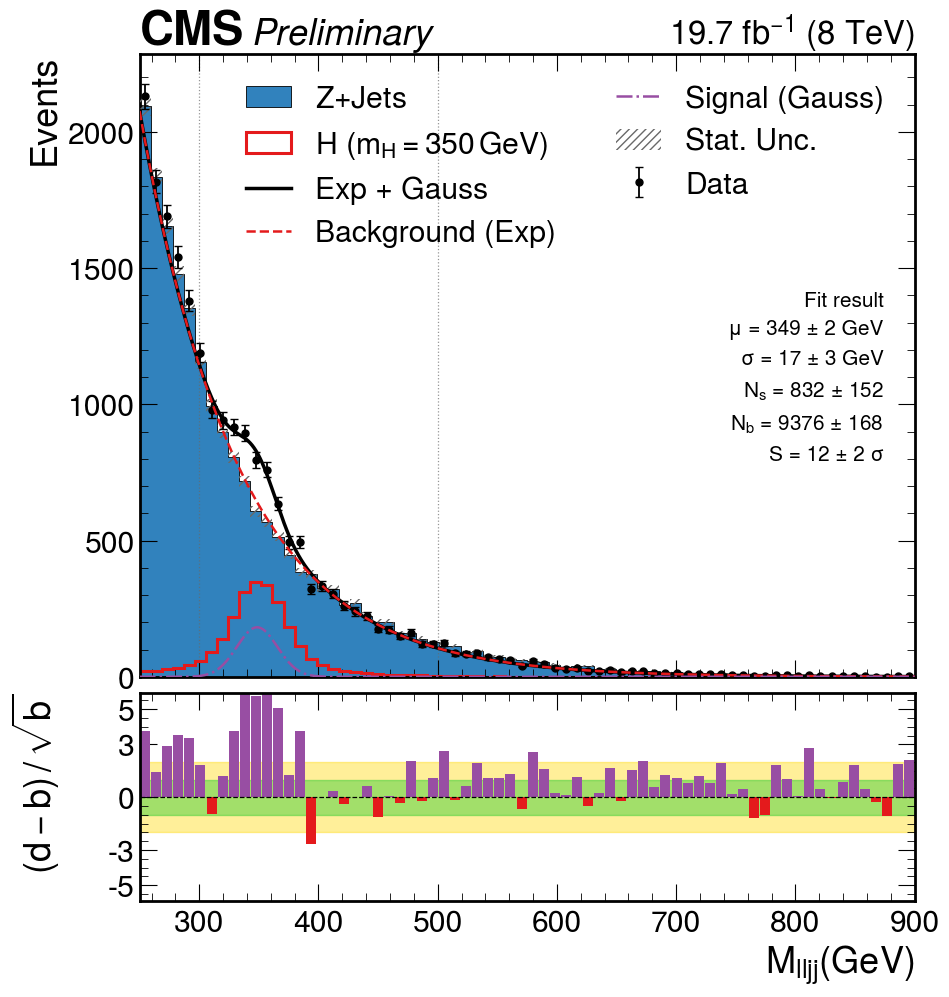

In [57]:
fig, ax, ax_pull = plot_cms_fit(
    df        = Data_ldMjj,
    var       = "Mlljj",
    x_range   = (250, 900),
    fit_range = (300, 500),   # region around the signal peak
    bins      = 70,
    xl        = r"$M_{lljj} (GeV)$",
    lumi_data = lumi_data,
    com       = 8,
    fit_unit  = "GeV",
    mc        = {
        "ZJets_ldMjj"    : {"df": ZJets_ldMjj,    "label": r"$Z$+Jets",             "lumi": lumi_zjets},
        "Higgs400_ldMjj" : {"df": Higgs350_ldMjj, "label": r"$H\ (m_H=350 \,\text{GeV})$", "lumi": lumi_higgs350, "type": "sig"},
    },
    p0 = {"mu": 400, "sigma": 20, "N_s": 50, "N_b": 500, "lam": 0.005},
)

figures_dir = "/content/drive/MyDrive/ExP-CMS/Figures"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Created directory: {figures_dir}")
else:
    print(f"Directory already exists: {figures_dir}")


plt.savefig(os.path.join(figures_dir, "Mlljj_Data_fit.pdf"), bbox_inches="tight")
plt.show()

In [62]:
print(len(Higgs350),len(Higgs350_ldMjj))
print(len(ZJets),len(ZJets_ldMjj))

71317 38898
406260 56528


In [64]:
38898/200000

0.19449

In [65]:
def compute_cross_section(
    N_s:       float,
    N_s_err:   float,
    L:         float,
    B:         float,
    N_after:   int,
    N_i:       int,
) -> dict:
    """
    Compute the cross section and its uncertainty from fit results.

    sigma_cs = N_s / (L * B * epsilon)
    epsilon  = N_after / N_i

    Uncertainty is propagated from N_s and epsilon (MC statistical) in quadrature.
    L and B are treated as exact.

    Parameters
    ----------
    N_s     : Signal yield from the fit.
    N_s_err : 1σ uncertainty on N_s from the fit.
    L       : Integrated luminosity in fb⁻¹.
    B       : Branching ratio (dimensionless).
    N_after : MC events passing the selection.
    N_i     : Total MC events generated.

    Returns
    -------
    dict with keys:
        epsilon          : Selection efficiency.
        epsilon_err      : Statistical uncertainty on epsilon.
        cross_section    : Cross section in fb.
        cross_section_err: 1σ uncertainty on the cross section in fb.
        cross_section_pb : Cross section in pb.
        cross_section_err_pb : 1σ uncertainty in pb.
    """
    epsilon     = N_after / N_i
    epsilon_err = np.sqrt(N_after) / N_i   # MC statistical: sqrt(N_after)/N_i

    denominator = L * B * epsilon

    sigma_cs    = N_s / denominator

    # Error propagation: (δσ/σ)² = (δN_s/N_s)² + (δε/ε)²
    rel_err     = np.sqrt((N_s_err / N_s) ** 2 + (epsilon_err / epsilon) ** 2)
    sigma_cs_err = sigma_cs * rel_err

    print("=" * 45)
    print(f"  ε          = {epsilon:.5f} ± {epsilon_err:.5f}")
    print(f"  L·B·ε      = {denominator:.5f} fb⁻¹")
    print(f"  σ          = {sigma_cs:.1f} ± {sigma_cs_err:.1f} fb")
    print(f"  σ          = {sigma_cs/1e3:.4f} ± {sigma_cs_err/1e3:.4f} pb")
    print("=" * 45)

    return {
        "epsilon":            epsilon,
        "epsilon_err":        epsilon_err,
        "cross_section":      sigma_cs,
        "cross_section_err":  sigma_cs_err,
        "cross_section_pb":   sigma_cs     / 1e3,
        "cross_section_err_pb": sigma_cs_err / 1e3,
    }

In [66]:
result = compute_cross_section(
    N_s     = 832,
    N_s_err = 152,
    L       = 19.7,
    B       = 0.028,
    N_after = 38898,
    N_i     = 200000,
)

  ε          = 0.19449 ± 0.00099
  L·B·ε      = 0.10728 fb⁻¹
  σ          = 7755.4 ± 1417.4 fb
  σ          = 7.7554 ± 1.4174 pb
